In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Dataset 

In [89]:
file_path = "Merged_TSQIC_REDCap.xlsx" 
merged_final_tsqic_redcap_access = pd.read_excel(file_path)
merged_final_tsqic_redcap_access

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,los,redcap_event_name,redcap_repeat_instrument,...,a_e6,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete
0,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgical_pathology,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,postoperative_course,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2006-09-13,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,2007-02-05,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6591,1781,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6592,1781,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6593,1782,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6594,1785,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgical_pathology,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
# First, find the earliest operation_date for each patient
earliest_operation = merged_final_tsqic_redcap_access.groupby('id')['operation_date'].min().reset_index()
earliest_operation.columns = ['id', 'earliest_operation_date']

# Filter patients whose earliest operation_date is on or after 2021-01-01
patients_2021_onwards = earliest_operation[earliest_operation['earliest_operation_date'] >= '2021-01-01']['id']

print(f"Number of patients with earliest operation on or after 2021-01-01: {len(patients_2021_onwards)}")

# Filter the main dataframe to only include these patients
filtered_df = merged_final_tsqic_redcap_access[merged_final_tsqic_redcap_access['id'].isin(patients_2021_onwards)]

print(f"Total rows for these patients: {len(filtered_df)}")

# Count how many icu_duration values are available (not NA) - this includes 0 values
icu_duration_available = filtered_df['icu_duration'].notna().sum()

print(f"Number of rows with icu_duration available (not NA, including 0): {icu_duration_available}")

# Show breakdown by patient - count of non-NA icu_duration values per patient
patient_icu_counts = filtered_df.groupby('id')['icu_duration'].apply(lambda x: x.notna().sum()).reset_index()
patient_icu_counts.columns = ['id', 'icu_duration_available_count']

# Patients with at least one icu_duration value (including 0)
patients_with_data = (patient_icu_counts['icu_duration_available_count'] > 0).sum()
print(f"Patients with at least one icu_duration value available: {patients_with_data}")

# Show actual icu_duration values (including 0s)
print(f"\nSample of actual icu_duration values:")
sample_data = filtered_df[filtered_df['icu_duration'].notna()][['id', 'operation_date', 'icu_duration']].head(20)
print(sample_data)

# Show value counts for icu_duration (including 0s)
print(f"\nicu_duration value distribution:")
print(filtered_df['icu_duration'].value_counts().sort_index())

Number of patients with earliest operation on or after 2021-01-01: 383
Total rows for these patients: 2097
Number of rows with icu_duration available (not NA, including 0): 802
Patients with at least one icu_duration value available: 139

Sample of actual icu_duration values:
        id operation_date  icu_duration
4015  1043     2021-02-23           0.0
4016  1043            NaT           0.0
4017  1043            NaT           0.0
4018  1043            NaT           0.0
4019  1043            NaT           0.0
4294  1113            NaT           0.0
4295  1113            NaT           0.0
4296  1113     2021-04-20           0.0
4297  1113            NaT           0.0
4298  1113            NaT           0.0
4299  1113            NaT           0.0
4300  1113            NaT           0.0
4319  1122            NaT           0.0
4320  1122            NaT           0.0
4321  1122            NaT           0.0
4322  1122            NaT           0.0
4323  1122     2021-07-28           0.0
433

In [91]:
len(merged_final_tsqic_redcap_access['id'].unique())

1609

In [92]:
# Convert operation_date to datetime format if it's not already
merged_final_tsqic_redcap_access['operation_date'] = pd.to_datetime(merged_final_tsqic_redcap_access['operation_date'], errors='coerce')

# Set the cutoff date
cutoff_date = pd.to_datetime('2021-01-01')

# Create a dictionary to store the earliest operation date for each patient
patient_earliest_dates = {}  # Changed name to reflect its purpose

# Iterate through the DataFrame to find the earliest operation date for each patient
for _, row in merged_final_tsqic_redcap_access.iterrows():
    patient_id = row['id']
    operation_date = row['operation_date']
    
    # Skip if operation_date is NaT
    if pd.isna(operation_date):
        continue
    
    # Update the earliest date for this patient
    # CHANGED: The comparison operator from > to < to get earliest instead of latest
    if patient_id not in patient_earliest_dates or operation_date < patient_earliest_dates[patient_id]:
        patient_earliest_dates[patient_id] = operation_date

# Find patients who had surgery on or after January 1, 2021
eligible_patients = [patient_id for patient_id, date in patient_earliest_dates.items()
                    if date >= cutoff_date]

# Filter the dataframe to include only eligible patients
filtered_merged_final_tsqic_redcap_access = merged_final_tsqic_redcap_access[merged_final_tsqic_redcap_access['id'].isin(eligible_patients)]

# Output information about the filtering
print(f"Total unique patients: {merged_final_tsqic_redcap_access['id'].nunique()}")
print(f"Patients with earliest surgery on or after Jan 1, 2021: {len(eligible_patients)}")
print(f"Total rows before filtering: {len(merged_final_tsqic_redcap_access)}")
print(f"Total rows after filtering: {len(filtered_merged_final_tsqic_redcap_access)}")

Total unique patients: 1609
Patients with earliest surgery on or after Jan 1, 2021: 383
Total rows before filtering: 6596
Total rows after filtering: 2097


In [93]:

# Find all patient IDs that have procedure 7 or 9
ids_with_esd_emr = filtered_merged_final_tsqic_redcap_access[filtered_merged_final_tsqic_redcap_access["procedure123456"].isin([7, 9])]["id"].unique()

# Remove all rows for those patient IDs
filtered_merged_final_tsqic_redcap_access = filtered_merged_final_tsqic_redcap_access[~filtered_merged_final_tsqic_redcap_access["id"].isin(ids_with_esd_emr)]

print(f"Removed {len(ids_with_esd_emr)} unique patient IDs that had ESD or EMR procedures")
print(f"Remaining rows: {len(filtered_merged_final_tsqic_redcap_access)}")

Removed 69 unique patient IDs that had ESD or EMR procedures
Remaining rows: 1792


In [94]:

# Find all patient IDs that have palliative surgery expectation (value 2)
ids_with_palliative = filtered_merged_final_tsqic_redcap_access[filtered_merged_final_tsqic_redcap_access["expectation_treatment"].isin([2])]["id"].unique()

# Remove all rows for those patient IDs
filtered_merged_final_tsqic_redcap_access = filtered_merged_final_tsqic_redcap_access[~filtered_merged_final_tsqic_redcap_access["id"].isin(ids_with_palliative)]

print(f"Removed {len(ids_with_palliative)} unique patient IDs that had palliative surgery expectation")
print(f"Remaining rows: {len(filtered_merged_final_tsqic_redcap_access)}")

Removed 20 unique patient IDs that had palliative surgery expectation
Remaining rows: 1650


In [95]:
filtered_merged_final_tsqic_redcap_access

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,los,redcap_event_name,redcap_repeat_instrument,...,a_e6,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete
276,76,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgical_pathology,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277,76,2021-05-18,Ileus,2.0,II - New Medication,0.0,2021-05-25,7.0,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
278,76,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
279,76,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,functional_assessment_of_cancer_therapy_fact_e...,...,1.0,0.0,0.0,0.0,4.0,17.0,32.0,40.0,NaN,2.0
280,76,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6582,1770,2025-03-14,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6583,1770,NaT,NaN,NaN,NaN,NaN,NaT,NaN,5_years_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6584,1770,NaT,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgical_pathology,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6589,1780,2025-05-21,NaN,NaN,NaN,NaN,NaT,NaN,surgery_arm_1,surgery_esd_emr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
len(filtered_merged_final_tsqic_redcap_access['id'].unique())

294

In [97]:
filtered_merged_final_tsqic_redcap_access['recurrence'].value_counts()


recurrence
0.0      148
1.0       53
999.0      2
Name: count, dtype: int64

In [98]:
filtered_merged_final_tsqic_redcap_access['recurrence_location___distant'].value_counts()


recurrence_location___distant
0.0    246
1.0     34
Name: count, dtype: int64

In [99]:
filtered_merged_final_tsqic_redcap_access['recurrence_location___ukn'].value_counts()


recurrence_location___ukn
0.0    280
Name: count, dtype: int64

In [100]:
filtered_merged_final_tsqic_redcap_access[
    filtered_merged_final_tsqic_redcap_access['id'].isin(patient_outcomes.keys())
]['recurrence'].value_counts()

recurrence
0.0      66
1.0      24
999.0     1
Name: count, dtype: int64

In [101]:
filtered_merged_final_tsqic_redcap_access[
    filtered_merged_final_tsqic_redcap_access['id'].isin(patient_outcomes.keys())
]['recurrence_location___distant'].value_counts()

recurrence_location___distant
0.0    95
1.0    15
Name: count, dtype: int64

# Analysis

### TBO 

In [102]:
merged_final_tsqic_redcap_access = filtered_merged_final_tsqic_redcap_access.copy()

In [103]:
# Group data by patient ID
patient_groups = merged_final_tsqic_redcap_access.groupby('id')

# Track results for each patient
patient_outcomes = {}
patient_missing_data = {}
patient_failed_criteria = {}
failed_criteria_counts = {
    'path_proximalmargin': 0,
    'path_distalmargin': 0,
    'path_circummargin': 0,
    'path_lymph_total': 0,
    'intraop_complications': 0,
    'Grade_3': 0,
    'Grade_4': 0,
    'Grade_5': 0,
    'Grade_6': 0,
    'Grade_7': 0,
    'Complication_not_leak': 0,
    'readmission_30d': 0,
    'los': 0,
    'icu_duration': 0
}

In [104]:
# Process each patient
for patient_id, patient_data in patient_groups:
    # First, check if any criterion is completely missing across all rows
    has_data_for_criterion = {
        'path_proximalmargin': False,
        'path_distalmargin': False,
        'path_circummargin': False,
        'path_lymph_total': False,
        'intraop_complications': False,
        'Grade': False,
        'Complication_not_leak': False,
        'readmission_30d': False,
        'los': False,
        'icu_duration': False
    }
    
    # Track if any criterion is violated
    criteria_violated = {
        'path_proximalmargin': False,
        'path_distalmargin': False,
        'path_circummargin': False,
        'path_lymph_total': False,
        'intraop_complications': False,
        'Grade': False,
        'Complication_not_leak': False,
        'readmission_30d': False,
        'los': False,
        'icu_duration': False
    }
    
    # First pass: check if each criterion has any data at all across all rows
    for _, row in patient_data.iterrows():
        if pd.notna(row['path_proximalmargin']):
            has_data_for_criterion['path_proximalmargin'] = True
            
        if pd.notna(row['path_distalmargin']):
            has_data_for_criterion['path_distalmargin'] = True
            
        if pd.notna(row['path_circummargin']):
            has_data_for_criterion['path_circummargin'] = True
            
        if pd.notna(row['path_lymph_total']):
            has_data_for_criterion['path_lymph_total'] = True
            
        if pd.notna(row['intraop_complications']):
            has_data_for_criterion['intraop_complications'] = True
            
        if pd.notna(row['Grade']):
            has_data_for_criterion['Grade'] = True
            
        if pd.notna(row['Complication']):
            has_data_for_criterion['Complication_not_leak'] = True
            
        if pd.notna(row['readmission_30d']):
            has_data_for_criterion['readmission_30d'] = True
            
        if pd.notna(row['los']):
            has_data_for_criterion['los'] = True
            
        if pd.notna(row['icu_duration']):
            has_data_for_criterion['icu_duration'] = True
    
    # Check if any criterion is completely missing across all rows
    missing_criteria = [criterion for criterion, has_data in has_data_for_criterion.items() if not has_data]
    has_missing_data = len(missing_criteria) > 0
    
    if has_missing_data:
        # Record which data is missing and exclude from outcome analysis
        patient_missing_data[patient_id] = missing_criteria
        continue
    
    # Second pass: now that we know all criteria have data somewhere, check if any criteria are violated
    criteria_met = {
        'path_proximalmargin': False,
        'path_distalmargin': False,
        'path_circummargin': False,
        'path_lymph_total': False,
        'intraop_complications': False,
        'Grade': False,
        'Complication_not_leak': False,
        'readmission_30d': False,
        'los': False,
        'icu_duration': False
    }
    
    for _, row in patient_data.iterrows():
        # Check each criterion for violations
        if pd.notna(row['path_proximalmargin']):
            if row['path_proximalmargin'] == 1:
                criteria_met['path_proximalmargin'] = True
            else:
                criteria_violated['path_proximalmargin'] = True
                
        if pd.notna(row['path_distalmargin']):
            if row['path_distalmargin'] == 1:
                criteria_met['path_distalmargin'] = True
            else:
                criteria_violated['path_distalmargin'] = True
                
        if pd.notna(row['path_circummargin']):
            if row['path_circummargin'] == 1:
                criteria_met['path_circummargin'] = True
            else:
                criteria_violated['path_circummargin'] = True
                
        if pd.notna(row['path_lymph_total']):
            if row['path_lymph_total'] >= 20:
                criteria_met['path_lymph_total'] = True
            else:
                criteria_violated['path_lymph_total'] = True
                
        if pd.notna(row['intraop_complications']):
            if row['intraop_complications'] == 0:
                criteria_met['intraop_complications'] = True
            else:
                criteria_violated['intraop_complications'] = True
                
        if pd.notna(row['Grade']):
            if row['Grade'] < 3:
                criteria_met['Grade'] = True
            else:
                criteria_violated['Grade'] = True
                
        if pd.notna(row['Complication']):
            if row['Complication'] != 'Leak':
                criteria_met['Complication_not_leak'] = True
            else:
                criteria_violated['Complication_not_leak'] = True
                
        if pd.notna(row['readmission_30d']):
            if row['readmission_30d'] == 0:
                criteria_met['readmission_30d'] = True
            else:
                criteria_violated['readmission_30d'] = True
                
        if pd.notna(row['los']):
            if row['los'] < 14:
                criteria_met['los'] = True
            else:
                criteria_violated['los'] = True
                
        if pd.notna(row['icu_duration']):
            if row['icu_duration'] == 0:
                criteria_met['icu_duration'] = True
            else:
                criteria_violated['icu_duration'] = True
    
    # For textbook outcome:
    # 1. Patient must have at least one value meeting each criterion
    all_criteria_met = all(criteria_met.values())
    # 2. Patient must not have any violation of any criterion
    no_criteria_violated = not any(criteria_violated.values())
    
    textbook_outcome = all_criteria_met and no_criteria_violated
    patient_outcomes[patient_id] = textbook_outcome
    
    # If patient doesn't achieve textbook outcome, record which criteria they failed
    if not textbook_outcome:
        patient_failed_criteria[patient_id] = {}
        
        # Record criteria that were not met (no positive value found)
        # for criterion, met in criteria_met.items():
        #     if not met:
        #         if criterion not in patient_failed_criteria[patient_id]:  # Only count once per patient
        #             failed_criteria_counts[criterion] += 1
        #         patient_failed_criteria[patient_id][criterion] = "no_positive_value"
                
        # Record criteria that were not met (no positive value found)
        for criterion, met in criteria_met.items():
            if not met:
                if criterion not in patient_failed_criteria[patient_id]:  # Only count once per patient
                    if criterion == 'Grade':
                        # For Grade not met, we need to check what grade value exists
                        grade_value = None
                        for _, row in patient_data.iterrows():
                            if pd.notna(row['Grade']):
                                grade_value = int(row['Grade'])
                                break
                        
                        if grade_value == 3:
                            failed_criteria_counts['Grade_3'] += 1
                        elif grade_value == 4:
                            failed_criteria_counts['Grade_4'] += 1
                        elif grade_value == 5:
                            failed_criteria_counts['Grade_5'] += 1
                        elif grade_value == 6:
                            failed_criteria_counts['Grade_6'] += 1
                        elif grade_value == 7:
                            failed_criteria_counts['Grade_7'] += 1
                        # If grade is =< 3, it shouldn't reach here, but handle just in case
                    else:
                        failed_criteria_counts[criterion] += 1
                patient_failed_criteria[patient_id][criterion] = "no_positive_value"
        
        # Record criteria that were violated
        # for criterion, violated in criteria_violated.items():
        #     if violated:
        #         if criterion not in patient_failed_criteria[patient_id]:  # Only count once per patient
        #             failed_criteria_counts[criterion] += 1
        #         patient_failed_criteria[patient_id][criterion] = "criterion_violated"
                
        for criterion, violated in criteria_violated.items():
            if violated:
                if criterion not in patient_failed_criteria[patient_id]:  # Only count once per patient
                    if criterion == 'Grade':
                        # For Grade failures, count by specific grade value
                        grade_value = None
                        for _, row in patient_data.iterrows():
                            if pd.notna(row['Grade']) and row['Grade'] >= 3:
                                grade_value = int(row['Grade'])
                                break
                        
                        if grade_value == 3:
                            failed_criteria_counts['Grade_3'] += 1
                        elif grade_value == 4:
                            failed_criteria_counts['Grade_4'] += 1
                        elif grade_value == 5:
                            failed_criteria_counts['Grade_5'] += 1
                        elif grade_value == 6:
                            failed_criteria_counts['Grade_6'] += 1
                        elif grade_value == 7:
                            failed_criteria_counts['Grade_7'] += 1
                    else:
                        failed_criteria_counts[criterion] += 1
                patient_failed_criteria[patient_id][criterion] = "criterion_violated"

In [105]:
patient_outcomes

{1113: False,
 1122: False,
 1135: False,
 1141: False,
 1145: False,
 1148: False,
 1150: True,
 1156: False,
 1164: True,
 1167: False,
 1168: False,
 1173: False,
 1175: False,
 1176: False,
 1179: False,
 1182: True,
 1187: False,
 1188: True,
 1189: True,
 1191: False,
 1195: False,
 1205: False,
 1206: True,
 1208: True,
 1212: False,
 1213: False,
 1214: False,
 1215: False,
 1219: False,
 1220: True,
 1223: True,
 1229: False,
 1232: False,
 1235: True,
 1236: False,
 1237: True,
 1239: False,
 1241: True,
 1251: False,
 1257: False,
 1268: True,
 1270: True,
 1271: False,
 1275: False,
 1276: False,
 1278: False,
 1280: False,
 1287: False,
 1296: True,
 1297: True,
 1303: False,
 1304: False,
 1309: False,
 1313: False,
 1314: True,
 1325: True,
 1332: True,
 1336: True,
 1337: False,
 1338: True,
 1341: True,
 1357: False,
 1361: True,
 1365: True,
 1373: False,
 1378: False,
 1380: True,
 1384: False,
 1386: True,
 1387: False,
 1398: False,
 1410: False,
 1411: True,
 1451

In [106]:
patient_missing_data

{76: ['intraop_complications', 'icu_duration'],
 468: ['path_proximalmargin',
  'path_distalmargin',
  'path_circummargin',
  'path_lymph_total',
  'intraop_complications',
  'Grade',
  'Complication_not_leak',
  'readmission_30d',
  'icu_duration'],
 1053: ['path_proximalmargin',
  'path_distalmargin',
  'path_circummargin',
  'path_lymph_total',
  'intraop_complications',
  'Grade',
  'Complication_not_leak',
  'readmission_30d',
  'icu_duration'],
 1086: ['path_proximalmargin',
  'path_distalmargin',
  'path_circummargin',
  'path_lymph_total',
  'intraop_complications',
  'icu_duration'],
 1095: ['path_proximalmargin',
  'path_distalmargin',
  'path_circummargin',
  'path_lymph_total',
  'intraop_complications',
  'Grade',
  'Complication_not_leak',
  'readmission_30d',
  'los',
  'icu_duration'],
 1097: ['Grade',
  'Complication_not_leak',
  'readmission_30d',
  'los',
  'icu_duration'],
 1111: ['path_proximalmargin',
  'path_distalmargin',
  'path_circummargin',
  'path_lymph_tot

In [107]:
patient_failed_criteria

{1113: {'path_lymph_total': 'criterion_violated',
  'los': 'criterion_violated',
  'Grade': 'criterion_violated',
  'Complication_not_leak': 'criterion_violated'},
 1122: {'Grade': 'criterion_violated', 'los': 'criterion_violated'},
 1135: {'path_circummargin': 'criterion_violated',
  'los': 'criterion_violated',
  'icu_duration': 'criterion_violated',
  'Grade': 'criterion_violated',
  'Complication_not_leak': 'criterion_violated'},
 1141: {'path_distalmargin': 'criterion_violated',
  'path_circummargin': 'criterion_violated',
  'path_lymph_total': 'criterion_violated'},
 1145: {'intraop_complications': 'criterion_violated'},
 1148: {'los': 'criterion_violated', 'Grade': 'criterion_violated'},
 1156: {'los': 'criterion_violated',
  'Grade': 'criterion_violated',
  'readmission_30d': 'criterion_violated'},
 1167: {'path_distalmargin': 'criterion_violated',
  'path_circummargin': 'criterion_violated'},
 1168: {'icu_duration': 'criterion_violated',
  'Grade': 'criterion_violated',
  'Com

In [108]:
# Calculate overall textbook outcome percentage
total_patients_with_complete_data = len(patient_outcomes)
textbook_outcome_count = sum(1 for outcome in patient_outcomes.values() if outcome)
textbook_outcome_percentage = (textbook_outcome_count / total_patients_with_complete_data) * 100 if total_patients_with_complete_data > 0 else 0

print(f"total_patients_with_complete_data: {total_patients_with_complete_data}")
print(f"textbook_outcome_count: {textbook_outcome_count}")
print(f"textbook_outcome_percentage: {textbook_outcome_percentage:.2f}%")


total_patients_with_complete_data: 110
textbook_outcome_count: 37
textbook_outcome_percentage: 33.64%


In [109]:
# Calculate overall textbook outcome percentage
total_patients_with_complete_data = len(patient_outcomes)
textbook_outcome_count = sum(1 for outcome in patient_outcomes.values() if outcome)
textbook_outcome_percentage = (textbook_outcome_count / total_patients_with_complete_data) * 100 if total_patients_with_complete_data > 0 else 0

# Calculate percentages for failed criteria
failed_patient_count = total_patients_with_complete_data - textbook_outcome_count
failed_criteria_percentages = {
    criterion: (count / failed_patient_count) * 100 
    for criterion, count in failed_criteria_counts.items()
} if failed_patient_count > 0 else {criterion: 0 for criterion in failed_criteria_counts}

# Total number of patients
total_patients = len(patient_groups)
missing_data_patients = len(patient_missing_data)

# Generate summary statistics
print(f"Total patients in dataset: {total_patients}")
print(f"Patients excluded due to missing data: {missing_data_patients} ({(missing_data_patients / total_patients) * 100:.2f}%)")
print(f"Patients included in analysis (complete data): {total_patients_with_complete_data} ({(total_patients_with_complete_data / total_patients) * 100:.2f}%)")
print(f"Patients with textbook outcome: {textbook_outcome_count} ({textbook_outcome_percentage:.2f}% of analyzed patients)")
print(f"Patients without textbook outcome: {failed_patient_count} ({100 - textbook_outcome_percentage:.2f}% of analyzed patients)")

print("\nBreakdown of failed criteria (among patients without textbook outcome):")
for criterion, count in failed_criteria_counts.items():
    percentage = failed_criteria_percentages[criterion]
    print(f"  {criterion}: {count} patients ({percentage:.2f}%)")

Total patients in dataset: 294
Patients excluded due to missing data: 184 (62.59%)
Patients included in analysis (complete data): 110 (37.41%)
Patients with textbook outcome: 37 (33.64% of analyzed patients)
Patients without textbook outcome: 73 (66.36% of analyzed patients)

Breakdown of failed criteria (among patients without textbook outcome):
  path_proximalmargin: 1 patients (1.37%)
  path_distalmargin: 2 patients (2.74%)
  path_circummargin: 10 patients (13.70%)
  path_lymph_total: 5 patients (6.85%)
  intraop_complications: 5 patients (6.85%)
  Grade_3: 31 patients (42.47%)
  Grade_4: 6 patients (8.22%)
  Grade_5: 22 patients (30.14%)
  Grade_6: 1 patients (1.37%)
  Grade_7: 0 patients (0.00%)
  Complication_not_leak: 24 patients (32.88%)
  readmission_30d: 5 patients (6.85%)
  los: 46 patients (63.01%)
  icu_duration: 27 patients (36.99%)


In [110]:
# Sort criteria by difficulty (most failed to least failed)
sorted_criteria = sorted(
    failed_criteria_counts.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nCriteria ranked by difficulty (most failed to least failed):")
for criterion, count in sorted_criteria:
    percentage = failed_criteria_percentages[criterion]
    print(f"  {criterion}: {count} patients ({percentage:.2f}%)")


Criteria ranked by difficulty (most failed to least failed):
  los: 46 patients (63.01%)
  Grade_3: 31 patients (42.47%)
  icu_duration: 27 patients (36.99%)
  Complication_not_leak: 24 patients (32.88%)
  Grade_5: 22 patients (30.14%)
  path_circummargin: 10 patients (13.70%)
  Grade_4: 6 patients (8.22%)
  path_lymph_total: 5 patients (6.85%)
  intraop_complications: 5 patients (6.85%)
  readmission_30d: 5 patients (6.85%)
  path_distalmargin: 2 patients (2.74%)
  path_proximalmargin: 1 patients (1.37%)
  Grade_6: 1 patients (1.37%)
  Grade_7: 0 patients (0.00%)


In [111]:
# Additional analysis on missing data
print("\nAnalysis of missing data:")
missing_criteria_counts = {criterion: 0 for criterion in has_data_for_criterion.keys()}
for patient_id, missing_criteria_list in patient_missing_data.items():
    for criterion in missing_criteria_list:
        missing_criteria_counts[criterion] += 1

print(f"Missing data patterns (total {missing_data_patients} patients excluded):")
for criterion, count in missing_criteria_counts.items():
    percentage = (count / missing_data_patients) * 100 if missing_data_patients > 0 else 0
    print(f"  {criterion}: {count} patients ({percentage:.2f}%)")


Analysis of missing data:
Missing data patterns (total 184 patients excluded):
  path_proximalmargin: 41 patients (22.28%)
  path_distalmargin: 41 patients (22.28%)
  path_circummargin: 40 patients (21.74%)
  path_lymph_total: 39 patients (21.20%)
  intraop_complications: 93 patients (50.54%)
  Grade: 122 patients (66.30%)
  Complication_not_leak: 122 patients (66.30%)
  readmission_30d: 122 patients (66.30%)
  los: 53 patients (28.80%)
  icu_duration: 173 patients (94.02%)


In [112]:
# Additional analysis: Combined margin analysis (STRICT VERSION)
print("\n" + "="*60)
print("DETAILED MARGIN ANALYSIS")
print("="*60)

# Analyze patients with complete data for margin-specific reporting
patients_with_all_margins_negative = 0
patients_with_margin_data = 0

for patient_id, patient_data in patient_groups:
    # Skip patients who were excluded due to missing data
    if patient_id in patient_missing_data:
        continue
    
    # Check if this patient has data for all three margins
    has_all_margin_data = False
    any_margin_positive = False  # Changed logic: look for ANY positive margin
    
    for _, row in patient_data.iterrows():
        if (pd.notna(row['path_proximalmargin']) and 
            pd.notna(row['path_distalmargin']) and 
            pd.notna(row['path_circummargin'])):
            has_all_margin_data = True
            
            # If ANY margin is not negative (!=1), patient fails
            if (row['path_proximalmargin'] != 1 or 
                row['path_distalmargin'] != 1 or 
                row['path_circummargin'] != 1):
                any_margin_positive = True
                break  # Found a positive margin, patient fails
    
    if has_all_margin_data:
        patients_with_margin_data += 1
        if not any_margin_positive:  # Patient passes only if NO positive margins found
            patients_with_all_margins_negative += 1

# Calculate percentages
patients_failed_all_margins = patients_with_margin_data - patients_with_all_margins_negative
all_margins_negative_percentage = (patients_with_all_margins_negative / patients_with_margin_data) * 100 if patients_with_margin_data > 0 else 0
failed_all_margins_percentage = (patients_failed_all_margins / patients_with_margin_data) * 100 if patients_with_margin_data > 0 else 0

print(f"Patients with complete margin data: {patients_with_margin_data}")
print(f"Patients with ALL three margins negative (strict): {patients_with_all_margins_negative} ({all_margins_negative_percentage:.2f}%)")
print(f"Patients who failed to have all three margins negative (strict): {patients_failed_all_margins} ({failed_all_margins_percentage:.2f}%)")


DETAILED MARGIN ANALYSIS
Patients with complete margin data: 110
Patients with ALL three margins negative (strict): 100 (90.91%)
Patients who failed to have all three margins negative (strict): 10 (9.09%)


In [113]:
# Check which patients have circumferential margin criterion violated
print("PATIENTS WITH CIRCUMFERENTIAL MARGIN CRITERION VIOLATED:")
print("="*60)

circumferential_violated_patients = []

for patient_id, failed_criteria in patient_failed_criteria.items():
    if 'path_circummargin' in failed_criteria and failed_criteria['path_circummargin'] == 'criterion_violated':
        circumferential_violated_patients.append(patient_id)

print(f"Number of patients with circumferential margin criterion violated: {len(circumferential_violated_patients)}")
print(f"Patient IDs: {circumferential_violated_patients}")

# Also show their full failed criteria for context
print(f"\nDetailed breakdown:")
for patient_id in circumferential_violated_patients:
    print(f"\nPatient {patient_id}:")
    for criterion, reason in patient_failed_criteria[patient_id].items():
        print(f"  {criterion}: {reason}")

# Compare with the 17 patients from strict margin analysis
print(f"\n" + "="*60)
print("COMPARISON:")
print(f"Patients with circumferential margin violation (TBO analysis): {len(circumferential_violated_patients)}")

PATIENTS WITH CIRCUMFERENTIAL MARGIN CRITERION VIOLATED:
Number of patients with circumferential margin criterion violated: 10
Patient IDs: [1135, 1141, 1167, 1229, 1275, 1304, 1373, 1451, 1527, 1531]

Detailed breakdown:

Patient 1135:
  path_circummargin: criterion_violated
  los: criterion_violated
  icu_duration: criterion_violated
  Grade: criterion_violated
  Complication_not_leak: criterion_violated

Patient 1141:
  path_distalmargin: criterion_violated
  path_circummargin: criterion_violated
  path_lymph_total: criterion_violated

Patient 1167:
  path_distalmargin: criterion_violated
  path_circummargin: criterion_violated

Patient 1229:
  path_proximalmargin: criterion_violated
  path_circummargin: criterion_violated
  los: criterion_violated
  Grade: criterion_violated

Patient 1275:
  path_circummargin: criterion_violated
  Grade: criterion_violated

Patient 1304:
  path_circummargin: criterion_violated
  Grade: criterion_violated
  los: criterion_violated

Patient 1373:
  p

In [114]:
# Print details of the 17 patients who failed strict margin criteria
print("\nDETAILS OF PATIENTS WHO FAILED STRICT MARGIN CRITERIA:")
print("="*80)

failed_margin_patients = []

for patient_id, patient_data in patient_groups:
    # Skip patients who were excluded due to missing data
    if patient_id in patient_missing_data:
        continue
    
    # Check if this patient has data for all three margins
    has_all_margin_data = False
    any_margin_positive = False
    failed_rows = []
    
    for idx, row in patient_data.iterrows():
        if (pd.notna(row['path_proximalmargin']) and 
            pd.notna(row['path_distalmargin']) and 
            pd.notna(row['path_circummargin'])):
            has_all_margin_data = True
            
            # Check which margins are positive
            margin_issues = []
            if row['path_proximalmargin'] != 1:
                margin_issues.append(f"proximal={row['path_proximalmargin']}")
            if row['path_distalmargin'] != 1:
                margin_issues.append(f"distal={row['path_distalmargin']}")
            if row['path_circummargin'] != 1:
                margin_issues.append(f"circumferential={row['path_circummargin']}")
            
            if margin_issues:
                any_margin_positive = True
                failed_rows.append({
                    'row_index': idx,
                    'operation_date': row['operation_date'],
                    'issues': margin_issues,
                    'proximal': row['path_proximalmargin'],
                    'distal': row['path_distalmargin'],
                    'circumferential': row['path_circummargin']
                })
    
    if has_all_margin_data and any_margin_positive:
        failed_margin_patients.append({
            'patient_id': patient_id,
            'failed_rows': failed_rows
        })

print(f"Total patients who failed: {len(failed_margin_patients)}")
print("\nDetailed breakdown:")

for i, patient in enumerate(failed_margin_patients, 1):
    print(f"\n{i}. Patient ID: {patient['patient_id']}")
    for row in patient['failed_rows']:
        print(f"   Row {row['row_index']} (Operation: {row['operation_date']}): {', '.join(row['issues'])}")
        print(f"   Margins: Proximal={row['proximal']}, Distal={row['distal']}, Circumferential={row['circumferential']}")

# Summary of which margins caused failures
print(f"\n" + "="*60)
print("SUMMARY OF MARGIN FAILURE TYPES:")
print("="*60)

proximal_failures = 0
distal_failures = 0
circumferential_failures = 0

for patient in failed_margin_patients:
    patient_proximal_fail = False
    patient_distal_fail = False
    patient_circumferential_fail = False
    
    for row in patient['failed_rows']:
        if row['proximal'] != 1 and not patient_proximal_fail:
            proximal_failures += 1
            patient_proximal_fail = True
        if row['distal'] != 1 and not patient_distal_fail:
            distal_failures += 1
            patient_distal_fail = True
        if row['circumferential'] != 1 and not patient_circumferential_fail:
            circumferential_failures += 1
            patient_circumferential_fail = True

print(f"Patients with proximal margin failures: {proximal_failures}")
print(f"Patients with distal margin failures: {distal_failures}")
print(f"Patients with circumferential margin failures: {circumferential_failures}")


DETAILS OF PATIENTS WHO FAILED STRICT MARGIN CRITERIA:
Total patients who failed: 10

Detailed breakdown:

1. Patient ID: 1135
   Row 4369 (Operation: NaT): circumferential=3.0
   Margins: Proximal=1.0, Distal=1.0, Circumferential=3.0

2. Patient ID: 1141
   Row 4401 (Operation: NaT): distal=2.0, circumferential=2.0
   Margins: Proximal=1.0, Distal=2.0, Circumferential=2.0

3. Patient ID: 1167
   Row 4502 (Operation: NaT): distal=2.0, circumferential=2.0
   Margins: Proximal=1.0, Distal=2.0, Circumferential=2.0

4. Patient ID: 1229
   Row 4806 (Operation: NaT): proximal=3.0, circumferential=3.0
   Margins: Proximal=3.0, Distal=1.0, Circumferential=3.0

5. Patient ID: 1275
   Row 4932 (Operation: NaT): circumferential=2.0
   Margins: Proximal=1.0, Distal=1.0, Circumferential=2.0

6. Patient ID: 1304
   Row 5054 (Operation: NaT): circumferential=2.0
   Margins: Proximal=1.0, Distal=1.0, Circumferential=2.0

7. Patient ID: 1373
   Row 5255 (Operation: NaT): circumferential=2.0
   Margins

In [115]:
# Check for patients with multiple margin information
print("CHECKING FOR PATIENTS WITH MULTIPLE MARGIN VALUES")
print("="*60)

patients_with_multiple_margin_data = []

for patient_id, patient_data in patient_groups:
    # Skip patients excluded due to missing data
    if patient_id in patient_missing_data:
        continue
    
    # Check each margin type for multiple values
    margin_types = ['path_proximalmargin', 'path_distalmargin', 'path_circummargin']
    
    for margin_type in margin_types:
        # Get all non-NA values for this margin type
        margin_values = patient_data[margin_type].dropna()
        unique_values = margin_values.unique()
        
        if len(unique_values) > 1:
            patients_with_multiple_margin_data.append({
                'patient_id': patient_id,
                'margin_type': margin_type,
                'values': unique_values,
                'all_values': margin_values.tolist()
            })
            print(f"Patient {patient_id} has multiple {margin_type} values: {unique_values}")

print(f"\nTotal instances of patients with conflicting margin data: {len(patients_with_multiple_margin_data)}")

# Also check how your current logic handles these cases
print("\nDETAILED CHECK: How current logic handles margin evaluation")
print("="*60)

circumferential_issues_detailed = 0
all_margins_negative_detailed = 0

for patient_id, patient_data in patient_groups:
    if patient_id in patient_missing_data:
        continue
        
    # Check circumferential margin logic (from your TBO code)
    circumferential_violated = False
    for _, row in patient_data.iterrows():
        if pd.notna(row['path_circummargin']):
            if row['path_circummargin'] != 1:  # Not negative
                circumferential_violated = True
                break
    
    # Check all margins negative logic (from additional code)
    all_margins_negative = False
    for _, row in patient_data.iterrows():
        if (pd.notna(row['path_proximalmargin']) and 
            pd.notna(row['path_distalmargin']) and 
            pd.notna(row['path_circummargin'])):
            if (row['path_proximalmargin'] == 1 and 
                row['path_distalmargin'] == 1 and 
                row['path_circummargin'] == 1):
                all_margins_negative = True
                break
    
    if circumferential_violated:
        circumferential_issues_detailed += 1
        
    if not all_margins_negative:
        all_margins_negative_detailed += 1
        
    # Show discrepancy cases
    if circumferential_violated and all_margins_negative:
        print(f"DISCREPANCY: Patient {patient_id} has circumferential violation but achieved all margins negative")
        print(patient_data[['path_proximalmargin', 'path_distalmargin', 'path_circummargin']].dropna())

print(f"\nCircumferential issues (detailed check): {circumferential_issues_detailed}")
print(f"Failed all margins negative (detailed check): {all_margins_negative_detailed}")

CHECKING FOR PATIENTS WITH MULTIPLE MARGIN VALUES



Total instances of patients with conflicting margin data: 0

DETAILED CHECK: How current logic handles margin evaluation

Circumferential issues (detailed check): 10
Failed all margins negative (detailed check): 10


In [116]:
# Detailed breakdown of the 17 patients by number of margin types failed
print("\nBREAKDOWN OF margin-failed PATIENTS BY NUMBER OF MARGIN TYPES FAILED:")
print("="*60)

one_margin_failed = 0
two_margins_failed = 0
three_margins_failed = 0

for patient in failed_margin_patients:  # From the earlier code that identified the 17 patients
    # Check which margin types this patient failed
    failed_margin_types = set()
    
    for row in patient['failed_rows']:
        if row['proximal'] != 1:
            failed_margin_types.add('proximal')
        if row['distal'] != 1:
            failed_margin_types.add('distal')
        if row['circumferential'] != 1:
            failed_margin_types.add('circumferential')
    
    num_failed_types = len(failed_margin_types)
    
    if num_failed_types == 1:
        one_margin_failed += 1
        print(f"Patient {patient['patient_id']}: 1 margin type failed ({list(failed_margin_types)[0]})")
    elif num_failed_types == 2:
        two_margins_failed += 1
        print(f"Patient {patient['patient_id']}: 2 margin types failed ({', '.join(failed_margin_types)})")
    elif num_failed_types == 3:
        three_margins_failed += 1
        print(f"Patient {patient['patient_id']}: 3 margin types failed (all)")

print(f"\nSUMMARY:")
print(f"Patients with 1 margin type failed: {one_margin_failed}")
print(f"Patients with 2 margin types failed: {two_margins_failed}")  
print(f"Patients with 3 margin types failed: {three_margins_failed}")
print(f"Total: {one_margin_failed + two_margins_failed + three_margins_failed}")


BREAKDOWN OF margin-failed PATIENTS BY NUMBER OF MARGIN TYPES FAILED:
Patient 1135: 1 margin type failed (circumferential)
Patient 1141: 2 margin types failed (circumferential, distal)
Patient 1167: 2 margin types failed (circumferential, distal)
Patient 1229: 2 margin types failed (proximal, circumferential)
Patient 1275: 1 margin type failed (circumferential)
Patient 1304: 1 margin type failed (circumferential)
Patient 1373: 1 margin type failed (circumferential)
Patient 1451: 1 margin type failed (circumferential)
Patient 1527: 1 margin type failed (circumferential)
Patient 1531: 1 margin type failed (circumferential)

SUMMARY:
Patients with 1 margin type failed: 7
Patients with 2 margin types failed: 3
Patients with 3 margin types failed: 0
Total: 10


### Define groups + Define long term outcomes and arrange by follow up period

In [36]:
from datetime import datetime

# Define follow-up groups based on surgery year
follow_up_groups = {
    '1-year': [2021, 2022, 2023],
    '2-year': [2021, 2022],
    '3-year': [2021],
    #'4-year': [2021]
}

# Convert operation_date to datetime if not already
if not pd.api.types.is_datetime64_dtype(merged_final_tsqic_redcap_access['operation_date']):
    merged_final_tsqic_redcap_access['operation_date'] = pd.to_datetime(
        merged_final_tsqic_redcap_access['operation_date'], errors='coerce'
    )

# Convert dod and last_fu_date to datetime if not already
date_columns = ['dod', 'last_fu_date']
for col in date_columns:
    if col in merged_final_tsqic_redcap_access.columns and not pd.api.types.is_datetime64_dtype(merged_final_tsqic_redcap_access[col]):
        merged_final_tsqic_redcap_access[col] = pd.to_datetime(
            merged_final_tsqic_redcap_access[col], errors='coerce'
        )

# Filter for patients with surgery from Jan 1, 2021 onwards
cutoff_date = pd.to_datetime('2021-01-01')

# We need to find the earliest operation_date for each patient, since one patient can have multiple rows
patient_op_dates = {}
for _, row in merged_final_tsqic_redcap_access.iterrows():
    patient_id = row['id']
    operation_date = row['operation_date']
    
    if pd.notna(operation_date):
        # Changed to track earliest operation date instead of latest
        if patient_id not in patient_op_dates or operation_date < patient_op_dates[patient_id]:
            patient_op_dates[patient_id] = operation_date

# Identify eligible patients with surgery from 2021 onwards
eligible_patients = [pid for pid, date in patient_op_dates.items() if date >= cutoff_date]

# Add surgery year to the dataframe for grouping
merged_final_tsqic_redcap_access['surgery_year'] = merged_final_tsqic_redcap_access['operation_date'].dt.year

# Calculate follow-up time
def calculate_follow_up_time(row):
    """Calculate the follow-up time in days"""
    if pd.notna(row['dod']):
        # For dead patients
        return (row['dod'] - row['operation_date']).days
    elif pd.notna(row['last_fu_date']):
        # For alive patients
        return (row['last_fu_date'] - row['operation_date']).days
    else:
        return np.nan

merged_final_tsqic_redcap_access['follow_up_days'] = merged_final_tsqic_redcap_access.apply(
    calculate_follow_up_time, axis=1
)


# Also create patient-level data for potential Kaplan-Meier analysis later
patient_level_data = []
for patient_id in eligible_patients:
    patient_data = merged_final_tsqic_redcap_access[
        merged_final_tsqic_redcap_access['id'] == patient_id
    ]
    
    # Get the operation date (using the one we already determined)
    op_date = patient_op_dates.get(patient_id)
    if op_date is None:
        continue
    
    # Determine if patient died
    died = patient_data['dod'].notna().any()
    death_date = patient_data.loc[patient_data['dod'].notna(), 'dod'].iloc[0] if died and any(patient_data['dod'].notna()) else None
    
    # Get the latest follow-up date
    last_fu = patient_data['last_fu_date'].max() if any(patient_data['last_fu_date'].notna()) else None
    
    # Calculate follow-up time
    if died and death_date is not None:
        follow_up_days = (death_date - op_date).days
        event = 1  # Death event occurred
    elif last_fu is not None:
        follow_up_days = (last_fu - op_date).days
        event = 0  # Censored (no death event)
    else:
        follow_up_days = np.nan
        event = np.nan
    
    # Check for recurrence and metastasis
    # For recurrence: prioritize 1, then 0, then NA/999
    if (patient_data['recurrence'] == 1).any():
        recurrence = 1
    elif (patient_data['recurrence'] == 0).any():
        recurrence = 0
    else:
        # This covers cases where all values are 999, NA, or missing
        recurrence = np.nan
    
    # For metastasis: prioritize 1, then 0, then NA
    if (patient_data['recurrence_location___distant'] == 1).any():
        metastasis = 1
    elif (patient_data['recurrence_location___distant'] == 0).any():
        metastasis = 0
    else:
        # This covers cases where all values are NA or missing
        metastasis = np.nan
    
    # TBO status from your previous analysis
    tbo = patient_outcomes.get(patient_id, False)
    
    # Surgery year
    surgery_year = op_date.year if op_date is not None else None
    
    # Add to patient level data
    patient_level_data.append({
        'patient_id': patient_id,
        'surgery_date': op_date,
        'surgery_year': surgery_year,
        'died': died,
        'death_date': death_date,
        'last_follow_up': last_fu,
        'follow_up_days': follow_up_days,
        'event': event,
        'recurrence': recurrence,
        'metastasis': metastasis,
        'tbo_achieved': tbo
    })

# Create the patient-level dataframe
patient_df = pd.DataFrame(patient_level_data)

print("\nAnalysis complete.")

/tmp/ipykernel_4020410/4271989702.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_final_tsqic_redcap_access[col] = pd.to_datetime(
/tmp/ipykernel_4020410/4271989702.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_final_tsqic_redcap_access[col] = pd.to_datetime(



Analysis complete.


In [37]:
# summary_df

In [38]:
patient_df

,patient_id,surgery_date,surgery_year,died,death_date,last_follow_up,follow_up_days,event,recurrence,metastasis,tbo_achieved
0,76,2021-05-18,2021,True,2024-04-13,2024-03-21,1061.0,1.0,1.0,0.0,False
1,468,2021-02-02,2021,False,NaT,2021-03-02,28.0,0.0,NaN,0.0,False
2,1053,2021-01-06,2021,False,NaT,2021-03-26,79.0,0.0,NaN,0.0,False
3,1086,2021-03-24,2021,False,NaT,2021-05-03,40.0,0.0,0.0,0.0,False
4,1095,2023-06-17,2023,False,NaT,2023-06-17,0.0,0.0,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...
289,1752,2025-02-05,2025,False,NaT,2025-03-10,33.0,0.0,0.0,0.0,False
290,1764,2025-02-25,2025,False,NaT,2025-03-10,13.0,0.0,NaN,0.0,False
291,1765,2025-04-08,2025,False,NaT,2025-05-05,27.0,0.0,0.0,0.0,False
292,1770,2025-03-14,2025,False,NaT,2025-05-02,49.0,0.0,NaN,0.0,False


In [39]:
# First, filter patient_df to only include patients in patient_outcomes
patients_in_analysis = list(patient_outcomes.keys())
filtered_patient_df = patient_df[patient_df['patient_id'].isin(patients_in_analysis)]

print(f"Total patients in original patient_df: {len(patient_df)}")
print(f"Patients included in analysis: {len(filtered_patient_df)}")

# Define follow-up groups based on surgery year
follow_up_groups = {
    '1-year': [2021, 2022, 2023],
    '2-year': [2021, 2022],
    '3-year': [2021],
    #'4-year': [2021]
}

# Calculate outcomes for each follow-up period using filtered_patient_df
new_results = {}

for period, years in follow_up_groups.items():
    # Filter for patients who had surgery in the relevant years
    period_df = filtered_patient_df[filtered_patient_df['surgery_year'].isin(years)]
    
    # Skip if no patients in this period
    if len(period_df) == 0:
        continue
    
    # Split by TBO status
    tbo_df = period_df[period_df['tbo_achieved'] == True]
    non_tbo_df = period_df[period_df['tbo_achieved'] == False]
    
    # Calculate patient counts
    new_results[period] = {
        'total_patients': len(period_df),
        'tbo_patients': len(tbo_df),
        'non_tbo_patients': len(non_tbo_df),
    }
    
    # Calculate outcomes for TBO and non-TBO groups
    for group_name, group_df in [('tbo', tbo_df), ('non_tbo', non_tbo_df)]:
        # Skip if no patients in this group
        if len(group_df) == 0:
            new_results[period][f'{group_name}_survival_rate'] = np.nan
            new_results[period][f'{group_name}_recurrence_rate'] = np.nan
            new_results[period][f'{group_name}_metastasis_rate'] = np.nan
            continue
        
        # Calculate survival rate (1 - proportion of deaths)
        deaths = group_df['died'].sum()
        survival_rate = 1 - (deaths / len(group_df))
        new_results[period][f'{group_name}_survival_rate'] = survival_rate
        
        # Calculate recurrence rate
        recurrences = group_df['recurrence'].sum()
        recurrence_rate = recurrences / len(group_df)
        new_results[period][f'{group_name}_recurrence_rate'] = recurrence_rate
        
        # Calculate metastasis rate
        metastases = group_df['metastasis'].sum()
        metastasis_rate = metastases / len(group_df)
        new_results[period][f'{group_name}_metastasis_rate'] = metastasis_rate

# Create a new summary dataframe
new_summary_data = []
for period, period_results in new_results.items():
    row = {
        'Follow-up Period': period,
        'Surgery Years': ', '.join(map(str, follow_up_groups[period])),
        'Total Patients': period_results['total_patients'],
        'TBO Patients': period_results['tbo_patients'],
        'Non-TBO Patients': period_results['non_tbo_patients'],
        'TBO Survival Rate': f"{period_results.get('tbo_survival_rate', np.nan):.2%}",
        'Non-TBO Survival Rate': f"{period_results.get('non_tbo_survival_rate', np.nan):.2%}",
        'TBO Recurrence Rate': f"{period_results.get('tbo_recurrence_rate', np.nan):.2%}",
        'Non-TBO Recurrence Rate': f"{period_results.get('non_tbo_recurrence_rate', np.nan):.2%}",
        'TBO Metastasis Rate': f"{period_results.get('tbo_metastasis_rate', np.nan):.2%}",
        'Non-TBO Metastasis Rate': f"{period_results.get('non_tbo_metastasis_rate', np.nan):.2%}",
    }
    new_summary_data.append(row)

# Create the new summary dataframe
new_summary_df = pd.DataFrame(new_summary_data)

# Display the new summary
print("\nUpdated Summary Table:")
print(new_summary_df.to_string(index=False))

Total patients in original patient_df: 294
Patients included in analysis: 110

Updated Summary Table:
Follow-up Period    Surgery Years  Total Patients  TBO Patients  Non-TBO Patients TBO Survival Rate Non-TBO Survival Rate TBO Recurrence Rate Non-TBO Recurrence Rate TBO Metastasis Rate Non-TBO Metastasis Rate
          1-year 2021, 2022, 2023             110            37                73            81.08%                68.49%              16.22%                  24.66%              10.81%                  15.07%
          2-year       2021, 2022              77            27                50            81.48%                56.00%              18.52%                  28.00%              11.11%                  16.00%
          3-year             2021              45            14                31            78.57%                51.61%              21.43%                  29.03%              14.29%                  19.35%


### Outcomes to Compare (Univariate Analysis) 

In [40]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

# Check if we can import from lifelines, if not we'll implement simpler alternatives
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    lifelines_available = True
except ImportError:
    lifelines_available = False
    print("Warning: lifelines package not available. Using simplified analysis instead.")

# PART 1: Prepare data for analysis
# For patients with surgery from Jan 1, 2021 onwards (as in previous analysis)
cutoff_date = pd.to_datetime('2021-01-01')

# Find earliest operation date for each patient (changed from latest to earliest)
patient_op_dates = {}
for _, row in merged_final_tsqic_redcap_access.iterrows():
    patient_id = row['id']
    operation_date = row['operation_date']
    
    if pd.notna(operation_date):
        # Changed from > to < to track earliest date instead of latest
        if patient_id not in patient_op_dates or operation_date < patient_op_dates[patient_id]:
            patient_op_dates[patient_id] = operation_date

# Filter for eligible patients with surgery from 2021 onwards
eligible_patients = [pid for pid, date in patient_op_dates.items() if date >= cutoff_date]

# Create patient-level dataset
patient_data = []
for patient_id in eligible_patients:
    # Get all rows for this patient
    pt_rows = merged_final_tsqic_redcap_access[merged_final_tsqic_redcap_access['id'] == patient_id]
    
    # Get operation date
    op_date = patient_op_dates.get(patient_id)
    if op_date is None:
        continue
    
    # Check if patient died
    died = pt_rows['dod'].notna().any()
    death_date = pt_rows.loc[pt_rows['dod'].notna(), 'dod'].iloc[0] if died and any(pt_rows['dod'].notna()) else None
    
    # Calculate survival time
    if died and death_date is not None:
        survival_time = (death_date - op_date).days
        death_event = 1
    else:
        # Get the last follow-up date
        last_fu = pt_rows['last_fu_date'].max() if any(pt_rows['last_fu_date'].notna()) else None
        if last_fu is not None:
            survival_time = (last_fu - op_date).days
        else:
            survival_time = np.nan
        death_event = 0
    
    # Get DFS value
    dfs = pt_rows['dfs'].dropna()
    dfs_value = dfs.iloc[0] if len(dfs) > 0 else np.nan
    
    # Check for recurrence with prioritized logic
    if (pt_rows['recurrence'] == 1).any():
        has_recurrence = 1
    elif (pt_rows['recurrence'] == 0).any():
        has_recurrence = 0
    else:
        # This covers cases where all values are 999, NA, or missing
        has_recurrence = np.nan
    
    # Check for metastasis with prioritized logic
    if (pt_rows['recurrence_location___distant'] == 1).any():
        has_metastasis = 1
    elif (pt_rows['recurrence_location___distant'] == 0).any():
        has_metastasis = 0
    else:
        # This covers cases where all values are NA or missing
        has_metastasis = np.nan
    
    # TBO status
    tbo_status = patient_outcomes.get(patient_id, False)
    
    # Add to dataset
    patient_data.append({
        'patient_id': patient_id,
        'tbo': tbo_status,
        'survival_time': survival_time,
        'death_event': death_event,
        'dfs': dfs_value,
        'recurrence': has_recurrence,
        'metastasis': has_metastasis
    })

# Create dataframe
patient_df = pd.DataFrame(patient_data)

# Print summary of data
print(f"Total patients: {len(patient_df)}")
print(f"TBO patients: {patient_df['tbo'].sum()}")
print(f"Non-TBO patients: {len(patient_df) - patient_df['tbo'].sum()}")

# PART 2: Survival Analysis
print("\n--- SURVIVAL ANALYSIS ---")

# Filter out patients with missing survival time or event data
survival_df = patient_df.dropna(subset=['survival_time', 'death_event'])
print(f"Patients with valid survival data: {len(survival_df)}")

# Split by TBO status
tbo_survival = survival_df[survival_df['tbo'] == True]
non_tbo_survival = survival_df[survival_df['tbo'] == False]

print(f"TBO patients with survival data: {len(tbo_survival)}")
print(f"Non-TBO patients with survival data: {len(non_tbo_survival)}")

# Check if we have enough data for log-rank test
if len(tbo_survival) > 0 and len(non_tbo_survival) > 0 and lifelines_available:
    try:
        # Count events in each group
        tbo_events = tbo_survival['death_event'].sum()
        non_tbo_events = non_tbo_survival['death_event'].sum()
        
        print(f"Events in TBO group: {tbo_events}")
        print(f"Events in non-TBO group: {non_tbo_events}")
        
        # Check if we have events in both groups
        if tbo_events > 0 or non_tbo_events > 0:
            # Perform log-rank test
            results = logrank_test(
                tbo_survival['survival_time'], 
                non_tbo_survival['survival_time'], 
                tbo_survival['death_event'], 
                non_tbo_survival['death_event']
            )
            print(f"Log-rank test p-value: {results.p_value:.4f}")
            
            # Print interpretation
            if results.p_value < 0.05:
                print("There is a statistically significant difference in survival between TBO and non-TBO groups")
            else:
                print("There is no statistically significant difference in survival between TBO and non-TBO groups")
        else:
            print("No death events recorded in either group. Cannot perform log-rank test.")
    except Exception as e:
        print(f"Error in log-rank test: {e}")
        print("Using simple comparison of survival rates instead")
        
        # Calculate survival rates
        tbo_survival_rate = 1 - (tbo_survival['death_event'].mean())
        non_tbo_survival_rate = 1 - (non_tbo_survival['death_event'].mean())
        
        print(f"TBO group survival rate: {tbo_survival_rate:.2%}")
        print(f"Non-TBO group survival rate: {non_tbo_survival_rate:.2%}")
else:
    print("Insufficient data to perform log-rank test for survival")
    
    # If we have any data, calculate simple rates
    if len(tbo_survival) > 0:
        tbo_survival_rate = 1 - (tbo_survival['death_event'].mean())
        print(f"TBO group survival rate: {tbo_survival_rate:.2%}")
    
    if len(non_tbo_survival) > 0:
        non_tbo_survival_rate = 1 - (non_tbo_survival['death_event'].mean())
        print(f"Non-TBO group survival rate: {non_tbo_survival_rate:.2%}")

# PART 3: Disease-Free Survival Analysis
print("\n--- DISEASE-FREE SURVIVAL ANALYSIS ---")

# Filter out patients with missing DFS
dfs_df = patient_df.dropna(subset=['dfs'])
print(f"Patients with valid DFS data: {len(dfs_df)}")

# Split by TBO status
tbo_dfs = dfs_df[dfs_df['tbo'] == True]
non_tbo_dfs = dfs_df[dfs_df['tbo'] == False]

print(f"TBO patients with DFS data: {len(tbo_dfs)}")
print(f"Non-TBO patients with DFS data: {len(non_tbo_dfs)}")

# Check if we have enough data for analysis
if len(tbo_dfs) > 0 and len(non_tbo_dfs) > 0 and lifelines_available:
    try:
        # We assume DFS values are time-to-event and all represent events
        tbo_dfs_events = np.ones(len(tbo_dfs))
        non_tbo_dfs_events = np.ones(len(non_tbo_dfs))
        
        # Perform log-rank test
        dfs_results = logrank_test(
            tbo_dfs['dfs'], 
            non_tbo_dfs['dfs'], 
            tbo_dfs_events, 
            non_tbo_dfs_events
        )
        print(f"Log-rank test p-value: {dfs_results.p_value:.4f}")
        
        # Print interpretation
        if dfs_results.p_value < 0.05:
            print("There is a statistically significant difference in disease-free survival between TBO and non-TBO groups")
        else:
            print("There is no statistically significant difference in disease-free survival between TBO and non-TBO groups")
    except Exception as e:
        print(f"Error in log-rank test for DFS: {e}")
        print("Using simple comparison of DFS values instead")
        
        # Calculate mean DFS for each group
        tbo_mean_dfs = tbo_dfs['dfs'].mean()
        non_tbo_mean_dfs = non_tbo_dfs['dfs'].mean()
        
        print(f"TBO group mean DFS: {tbo_mean_dfs:.1f} days")
        print(f"Non-TBO group mean DFS: {non_tbo_mean_dfs:.1f} days")
else:
    print("Insufficient data to perform log-rank test for DFS")
    
    # If we have any data, calculate simple means
    if len(tbo_dfs) > 0:
        tbo_mean_dfs = tbo_dfs['dfs'].mean()
        print(f"TBO group mean DFS: {tbo_mean_dfs:.1f} days")
    
    if len(non_tbo_dfs) > 0:
        non_tbo_mean_dfs = non_tbo_dfs['dfs'].mean()
        print(f"Non-TBO group mean DFS: {non_tbo_mean_dfs:.1f} days")

# PART 4: Metastatic Disease Analysis (Chi-square test)
print("\n--- METASTATIC DISEASE ANALYSIS ---")

# Filter out patients with missing metastasis data
meta_df = patient_df.dropna(subset=['metastasis'])
print(f"Patients with valid metastasis data: {len(meta_df)}")

# Split by TBO status
tbo_meta = meta_df[meta_df['tbo'] == True]
non_tbo_meta = meta_df[meta_df['tbo'] == False]

print(f"TBO patients with metastasis data: {len(tbo_meta)}")
print(f"Non-TBO patients with metastasis data: {len(non_tbo_meta)}")

# Create contingency table
if len(meta_df) > 0:
    contingency_table = pd.crosstab(meta_df['tbo'], meta_df['metastasis'])
    print("\nContingency Table:")
    print(contingency_table)
    
    # Check if we have enough data and variation for chi-square test
    valid_for_chi2 = True
    
    if len(contingency_table.columns) <= 1 or len(contingency_table.index) <= 1:
        print("Not enough variation in data for chi-square test")
        valid_for_chi2 = False
    
    if valid_for_chi2:
        try:
            # Check expected counts
            chi2, p, dof, expected = chi2_contingency(contingency_table)
            
            if (expected < 5).any():
                print("Warning: Some expected cell counts are less than 5. Chi-square results may be unreliable.")
            
            print(f"\nChi-square test p-value: {p:.4f}")
            
            # Print interpretation
            if p < 0.05:
                print("There is a statistically significant difference in metastatic disease rates between TBO and non-TBO groups")
            else:
                print("There is no statistically significant difference in metastatic disease rates between TBO and non-TBO groups")
        except Exception as e:
            print(f"Error in chi-square test: {e}")
            valid_for_chi2 = False
    
    # Calculate rates regardless of whether chi-square test was valid
    for tbo_value in [True, False]:
        if tbo_value in contingency_table.index:
            row = contingency_table.loc[tbo_value]
            
            # Check if True exists in columns
            if True in row.index:
                meta_count = row[True]
            else:
                meta_count = 0
            
            total = row.sum()
            rate = meta_count / total if total > 0 else 0
            
            group_name = "TBO" if tbo_value else "non-TBO"
            print(f"Metastatic disease rate in {group_name} group: {rate:.2%}")
else:
    print("No valid metastasis data available for analysis")

Total patients: 294
TBO patients: 37
Non-TBO patients: 257

--- SURVIVAL ANALYSIS ---
Patients with valid survival data: 279
TBO patients with survival data: 37
Non-TBO patients with survival data: 242
Events in TBO group: 7
Events in non-TBO group: 61
Log-rank test p-value: 0.0894
There is no statistically significant difference in survival between TBO and non-TBO groups

--- DISEASE-FREE SURVIVAL ANALYSIS ---
Patients with valid DFS data: 264
TBO patients with DFS data: 37
Non-TBO patients with DFS data: 227
Log-rank test p-value: 0.0276
There is a statistically significant difference in disease-free survival between TBO and non-TBO groups

--- METASTATIC DISEASE ANALYSIS ---
Patients with valid metastasis data: 280
TBO patients with metastasis data: 37
Non-TBO patients with metastasis data: 243

Contingency Table:
metastasis  0.0  1.0
tbo                 
False       213   30
True         33    4

Chi-square test p-value: 1.0000
There is no statistically significant difference in me

Total eligible patients with surgery from 2021 onwards: 294
Patients included in the analysis: 110



Patient data summary:
Total patients in analysis: 110
TBO patients: 37
Non-TBO patients: 73
Patients with death events: 30
Patients with recurrence: 24.0
Patients with metastasis: 15

--- SURVIVAL ANALYSIS ---
Patients with valid survival data: 110
TBO patients with survival data: 37
Non-TBO patients with survival data: 73
Deaths in TBO group: 7
Deaths in non-TBO group: 23
Log-rank test p-value: 0.2219
There is no statistically significant difference in survival between TBO and non-TBO groups


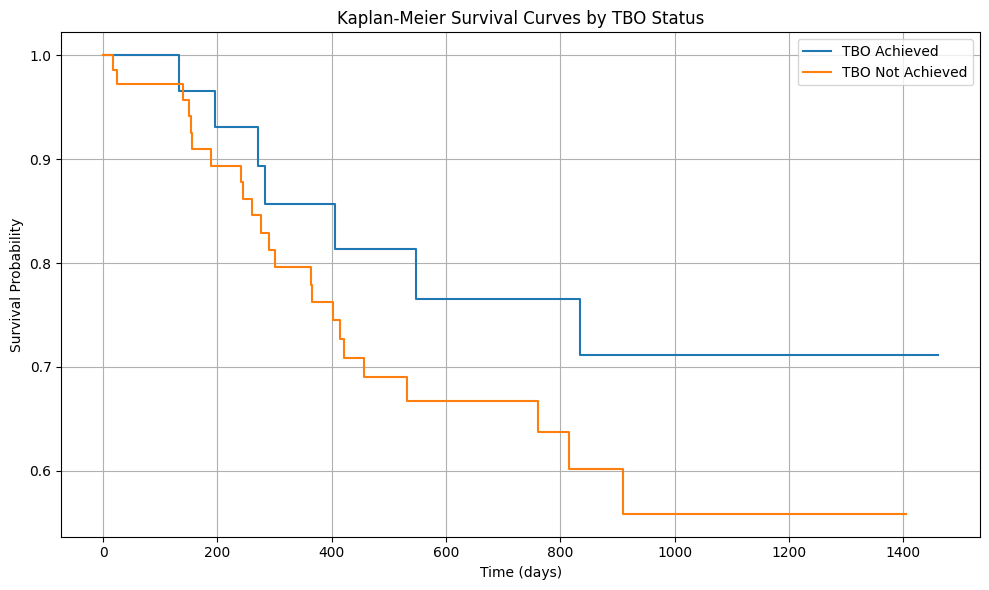


--- DISEASE-FREE SURVIVAL ANALYSIS ---
Patients with valid DFS data: 110
TBO patients with DFS data: 37
Non-TBO patients with DFS data: 73
Log-rank test p-value: 0.4704
There is no statistically significant difference in disease-free survival between TBO and non-TBO groups


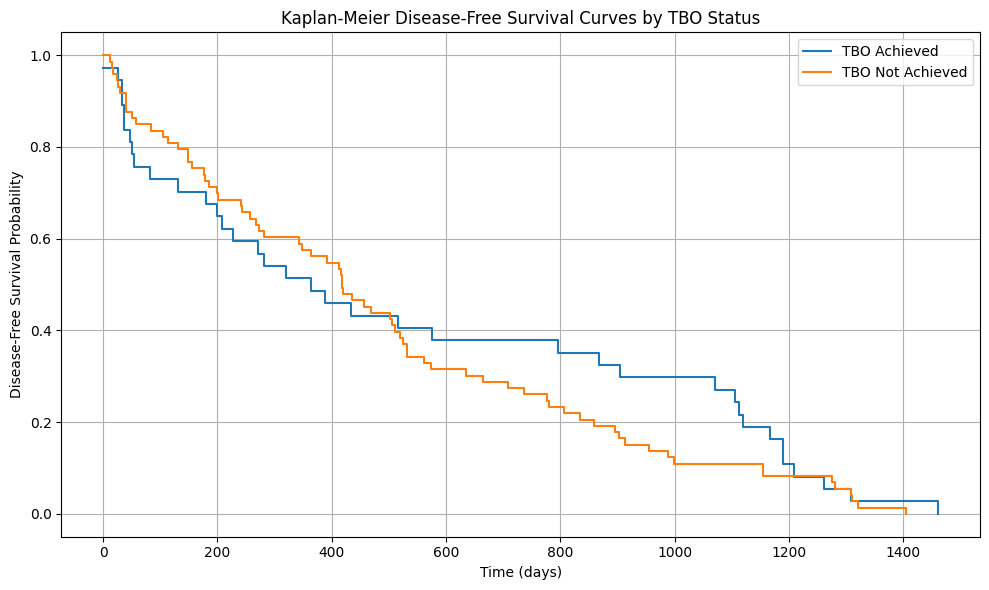


--- METASTATIC DISEASE ANALYSIS ---
Patients with valid metastasis data: 110
TBO patients with valid metastasis data: 37
Non-TBO patients with valid metastasis data: 73

Contingency Table (Metastasis):
metastasis   0   1
tbo               
False       62  11
True        33   4

Chi-square test p-value: 0.7484
There is no statistically significant difference in metastatic disease rates between TBO and non-TBO groups
Metastatic disease in TBO Achieved group: 4/37 (10.81%)
Metastatic disease in TBO Not Achieved group: 11/73 (15.07%)

Metastasis Summary Table:
           Group  Patients  Metastasis Count Metastasis Rate
    TBO Achieved        37                 4          10.81%
TBO Not Achieved        73                11          15.07%

--- RECURRENCE ANALYSIS ---
Patients with valid recurrence data: 90

Contingency Table (Recurrence):
recurrence  0.0  1.0
tbo                 
False        43   18
True         23    6

Chi-square test p-value: 0.5293
There is no statistically signific

In [41]:

from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

# Check if we can import from lifelines, if not we'll implement simpler alternatives
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    lifelines_available = True
except ImportError:
    lifelines_available = False
    print("Warning: lifelines package not available. Using simplified analysis instead.")

# PART 1: Prepare data for analysis
# For patients with surgery from Jan 1, 2021 onwards (as in previous analysis)
cutoff_date = pd.to_datetime('2021-01-01')

# Find earliest operation date for each patient (changed from latest to earliest)
patient_op_dates = {}
for _, row in merged_final_tsqic_redcap_access.iterrows():
    patient_id = row['id']
    operation_date = row['operation_date']
    
    if pd.notna(operation_date):
        # Changed from > to < to find earliest date instead of latest
        if patient_id not in patient_op_dates or operation_date < patient_op_dates[patient_id]:
            patient_op_dates[patient_id] = operation_date

# Filter for eligible patients with surgery from 2021 onwards
eligible_patients = [pid for pid, date in patient_op_dates.items() if date >= cutoff_date]

# IMPORTANT: Only include patients in the patient_outcomes dictionary
patients_in_analysis = list(patient_outcomes.keys())
analysis_patients = [pid for pid in eligible_patients if pid in patients_in_analysis]

print(f"Total eligible patients with surgery from 2021 onwards: {len(eligible_patients)}")
print(f"Patients included in the analysis: {len(analysis_patients)}")

# Create patient-level dataset
patient_data = []
for patient_id in analysis_patients:  # Only process patients in analysis
    # Get all rows for this patient
    pt_rows = merged_final_tsqic_redcap_access[merged_final_tsqic_redcap_access['id'] == patient_id]
    
    # Get operation date
    op_date = patient_op_dates.get(patient_id)
    if op_date is None:
        continue
    
    # Check if patient died
    died = pt_rows['dod'].notna().any()
    death_date = pt_rows.loc[pt_rows['dod'].notna(), 'dod'].iloc[0] if died and any(pt_rows['dod'].notna()) else None
    
    # Calculate survival time
    if died and death_date is not None:
        survival_time = (death_date - op_date).days
        death_event = 1
    else:
        # Get the latest follow-up date
        last_fu = pt_rows['last_fu_date'].max() if any(pt_rows['last_fu_date'].notna()) else None
        if last_fu is not None:
            survival_time = (last_fu - op_date).days
        else:
            survival_time = np.nan
        death_event = 0
    
    # Convert survival_time to float to ensure compatibility
    if pd.notna(survival_time):
        survival_time = float(survival_time)
    
    # Get DFS value
    dfs = pt_rows['dfs'].dropna()
    dfs_value = dfs.iloc[0] if len(dfs) > 0 else np.nan
    
    # Check for recurrence with prioritized logic
    if (pt_rows['recurrence'] == 1).any():
        has_recurrence = 1
    elif (pt_rows['recurrence'] == 0).any():
        has_recurrence = 0
    else:
        # This covers cases where all values are 999, NA, or missing
        has_recurrence = np.nan
    
    # Check for metastasis with prioritized logic
    if (pt_rows['recurrence_location___distant'] == 1).any():
        has_metastasis = 1
    elif (pt_rows['recurrence_location___distant'] == 0).any():
        has_metastasis = 0
    else:
        # This covers cases where all values are NA or missing
        has_metastasis = np.nan
    
    # TBO status from patient_outcomes
    tbo_status = patient_outcomes.get(patient_id, False)
    
    # Add to dataset
    patient_data.append({
        'patient_id': patient_id,
        'tbo': tbo_status,
        'survival_time': survival_time,
        'death_event': death_event,
        'dfs': dfs_value,
        'recurrence': has_recurrence,
        'metastasis': has_metastasis,
        'surgery_year': op_date.year if op_date is not None else None
    })

# Create dataframe
patient_df = pd.DataFrame(patient_data)

# Print summary of data
print(f"\nPatient data summary:")
print(f"Total patients in analysis: {len(patient_df)}")
print(f"TBO patients: {patient_df['tbo'].sum()}")
print(f"Non-TBO patients: {len(patient_df) - patient_df['tbo'].sum()}")
print(f"Patients with death events: {patient_df['death_event'].sum()}")
print(f"Patients with recurrence: {patient_df['recurrence'].sum()}")
print(f"Patients with metastasis: {patient_df['metastasis'].sum()}")

# PART 2: Survival Analysis
print("\n--- SURVIVAL ANALYSIS ---")

# Filter out patients with missing survival time or event data
survival_df = patient_df.dropna(subset=['survival_time', 'death_event'])
print(f"Patients with valid survival data: {len(survival_df)}")

# Split by TBO status
tbo_survival = survival_df[survival_df['tbo'] == True]
non_tbo_survival = survival_df[survival_df['tbo'] == False]

print(f"TBO patients with survival data: {len(tbo_survival)}")
print(f"Non-TBO patients with survival data: {len(non_tbo_survival)}")

# Check if we have enough data for log-rank test
if len(tbo_survival) > 0 and len(non_tbo_survival) > 0 and lifelines_available:
    try:
        # Count events in each group
        tbo_events = tbo_survival['death_event'].sum()
        non_tbo_events = non_tbo_survival['death_event'].sum()
        
        print(f"Deaths in TBO group: {tbo_events}")
        print(f"Deaths in non-TBO group: {non_tbo_events}")
        
        # Check if we have events in both groups
        if tbo_events > 0 or non_tbo_events > 0:
            # Ensure data is numeric
            tbo_times = tbo_survival['survival_time'].astype(float)
            non_tbo_times = non_tbo_survival['survival_time'].astype(float)
            tbo_events_arr = tbo_survival['death_event'].astype(int)
            non_tbo_events_arr = non_tbo_survival['death_event'].astype(int)
            
            # Perform log-rank test
            results = logrank_test(
                tbo_times, 
                non_tbo_times, 
                tbo_events_arr, 
                non_tbo_events_arr
            )
            print(f"Log-rank test p-value: {results.p_value:.4f}")
            
            # Print interpretation
            if results.p_value < 0.05:
                print("There is a statistically significant difference in survival between TBO and non-TBO groups")
            else:
                print("There is no statistically significant difference in survival between TBO and non-TBO groups")
            
            # Create Kaplan-Meier curves
            plt.figure(figsize=(10, 6))
            kmf = KaplanMeierFitter()
            
            if len(tbo_survival) > 0 and tbo_events > 0:
                kmf.fit(tbo_times, tbo_events_arr, label="TBO Achieved")
                kmf.plot_survival_function(ci_show=False)
            
            if len(non_tbo_survival) > 0 and non_tbo_events > 0:
                kmf.fit(non_tbo_times, non_tbo_events_arr, label="TBO Not Achieved")
                kmf.plot_survival_function(ci_show=False)
            
            plt.title('Kaplan-Meier Survival Curves by TBO Status')
            plt.xlabel('Time (days)')
            plt.ylabel('Survival Probability')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
            
        else:
            print("Not enough death events to perform meaningful log-rank test.")
    except Exception as e:
        print(f"Error in log-rank test: {e}")
        print("Using simple comparison of survival rates instead")
        
        # Calculate survival rates
        tbo_survival_rate = 1 - (tbo_survival['death_event'].mean())
        non_tbo_survival_rate = 1 - (non_tbo_survival['death_event'].mean())
        
        print(f"TBO group survival rate: {tbo_survival_rate:.2%}")
        print(f"Non-TBO group survival rate: {non_tbo_survival_rate:.2%}")
else:
    print("Insufficient data to perform log-rank test for survival")
    
    # If we have any data, calculate simple rates
    if len(tbo_survival) > 0:
        tbo_survival_rate = 1 - (tbo_survival['death_event'].mean())
        print(f"TBO group survival rate: {tbo_survival_rate:.2%}")
    
    if len(non_tbo_survival) > 0:
        non_tbo_survival_rate = 1 - (non_tbo_survival['death_event'].mean())
        print(f"Non-TBO group survival rate: {non_tbo_survival_rate:.2%}")

# PART 3: Disease-Free Survival Analysis
print("\n--- DISEASE-FREE SURVIVAL ANALYSIS ---")

# Filter out patients with missing DFS
dfs_df = patient_df.dropna(subset=['dfs'])
print(f"Patients with valid DFS data: {len(dfs_df)}")

# Split by TBO status
tbo_dfs = dfs_df[dfs_df['tbo'] == True]
non_tbo_dfs = dfs_df[dfs_df['tbo'] == False]

print(f"TBO patients with DFS data: {len(tbo_dfs)}")
print(f"Non-TBO patients with DFS data: {len(non_tbo_dfs)}")

# Check if we have enough data for analysis
if len(tbo_dfs) > 0 and len(non_tbo_dfs) > 0 and lifelines_available:
    try:
        # Ensure data is numeric
        tbo_dfs_times = tbo_dfs['dfs'].astype(float)
        non_tbo_dfs_times = non_tbo_dfs['dfs'].astype(float)
        
        # We assume DFS values are time-to-event and all represent events
        tbo_dfs_events = np.ones(len(tbo_dfs))
        non_tbo_dfs_events = np.ones(len(non_tbo_dfs))
        
        # Perform log-rank test
        dfs_results = logrank_test(
            tbo_dfs_times, 
            non_tbo_dfs_times, 
            tbo_dfs_events, 
            non_tbo_dfs_events
        )
        print(f"Log-rank test p-value: {dfs_results.p_value:.4f}")
        
        # Print interpretation
        if dfs_results.p_value < 0.05:
            print("There is a statistically significant difference in disease-free survival between TBO and non-TBO groups")
        else:
            print("There is no statistically significant difference in disease-free survival between TBO and non-TBO groups")
        
        # Create Kaplan-Meier curves for DFS
        plt.figure(figsize=(10, 6))
        kmf = KaplanMeierFitter()
        
        if len(tbo_dfs) > 0:
            kmf.fit(tbo_dfs_times, tbo_dfs_events, label="TBO Achieved")
            kmf.plot_survival_function(ci_show=False)
        
        if len(non_tbo_dfs) > 0:
            kmf.fit(non_tbo_dfs_times, non_tbo_dfs_events, label="TBO Not Achieved")
            kmf.plot_survival_function(ci_show=False)
        
        plt.title('Kaplan-Meier Disease-Free Survival Curves by TBO Status')
        plt.xlabel('Time (days)')
        plt.ylabel('Disease-Free Survival Probability')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error in log-rank test for DFS: {e}")
        print("Using simple comparison of DFS values instead")
        
        # Calculate mean DFS for each group
        tbo_mean_dfs = tbo_dfs['dfs'].mean()
        non_tbo_mean_dfs = non_tbo_dfs['dfs'].mean()
        
        print(f"TBO group mean DFS: {tbo_mean_dfs:.1f} days")
        print(f"Non-TBO group mean DFS: {non_tbo_mean_dfs:.1f} days")
else:
    print("Insufficient data to perform log-rank test for DFS")
    
    # If we have any data, calculate simple means
    if len(tbo_dfs) > 0:
        tbo_mean_dfs = tbo_dfs['dfs'].mean()
        print(f"TBO group mean DFS: {tbo_mean_dfs:.1f} days")
    
    if len(non_tbo_dfs) > 0:
        non_tbo_mean_dfs = non_tbo_dfs['dfs'].mean()
        print(f"Non-TBO group mean DFS: {non_tbo_mean_dfs:.1f} days")

# PART 4: Metastatic Disease Analysis (Chi-square test)
print("\n--- METASTATIC DISEASE ANALYSIS ---")

# Filter out patients with NA metastasis data
metastasis_valid_df = patient_df.dropna(subset=['metastasis'])
print(f"Patients with valid metastasis data: {len(metastasis_valid_df)}")

# Split by TBO status (using only patients with valid metastasis data)
tbo_patients = metastasis_valid_df[metastasis_valid_df['tbo'] == True]
non_tbo_patients = metastasis_valid_df[metastasis_valid_df['tbo'] == False]

print(f"TBO patients with valid metastasis data: {len(tbo_patients)}")
print(f"Non-TBO patients with valid metastasis data: {len(non_tbo_patients)}")

# Create contingency table
contingency_table = pd.crosstab(metastasis_valid_df['tbo'], metastasis_valid_df['metastasis'])
print("\nContingency Table (Metastasis):")
print(contingency_table)

# Check if we have enough data and variation for chi-square test
valid_for_chi2 = True

if len(contingency_table.columns) <= 1 or len(contingency_table.index) <= 1:
    print("Not enough variation in data for chi-square test")
    valid_for_chi2 = False

if valid_for_chi2:
    try:
        # Check expected counts
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        
        if (expected < 5).any():
            print("Warning: Some expected cell counts are less than 5. Chi-square results may be unreliable.")
        
        print(f"\nChi-square test p-value: {p:.4f}")
        
        # Print interpretation
        if p < 0.05:
            print("There is a statistically significant difference in metastatic disease rates between TBO and non-TBO groups")
        else:
            print("There is no statistically significant difference in metastatic disease rates between TBO and non-TBO groups")
    except Exception as e:
        print(f"Error in chi-square test: {e}")
        valid_for_chi2 = False

# Calculate rates using only patients with valid metastasis data
metastasis_summary = []
for tbo_value, group_name in [(True, "TBO Achieved"), (False, "TBO Not Achieved")]:
    group_df = metastasis_valid_df[metastasis_valid_df['tbo'] == tbo_value]
    if len(group_df) > 0:
        meta_count = group_df['metastasis'].sum()
        meta_rate = meta_count / len(group_df)
        
        metastasis_summary.append({
            "Group": group_name,
            "Patients": len(group_df),
            "Metastasis Count": meta_count,
            "Metastasis Rate": f"{meta_rate:.2%}"
        })
        
        print(f"Metastatic disease in {group_name} group: {meta_count}/{len(group_df)} ({meta_rate:.2%})")

metastasis_df = pd.DataFrame(metastasis_summary)
print("\nMetastasis Summary Table:")
print(metastasis_df.to_string(index=False))

# PART 5: Also create tables for recurrence
print("\n--- RECURRENCE ANALYSIS ---")

# Filter out patients with NA recurrence data
recurrence_valid_df = patient_df.dropna(subset=['recurrence'])
print(f"Patients with valid recurrence data: {len(recurrence_valid_df)}")

# Create contingency table for recurrence
recurrence_table = pd.crosstab(recurrence_valid_df['tbo'], recurrence_valid_df['recurrence'])
print("\nContingency Table (Recurrence):")
print(recurrence_table)

# Perform chi-square test for recurrence
if len(recurrence_table.columns) > 1 and len(recurrence_table.index) > 1:
    try:
        # Check expected counts
        chi2, p, dof, expected = chi2_contingency(recurrence_table)
        
        if (expected < 5).any():
            print("Warning: Some expected cell counts are less than 5. Chi-square results may be unreliable.")
        
        print(f"\nChi-square test p-value: {p:.4f}")
        
        # Print interpretation
        if p < 0.05:
            print("There is a statistically significant difference in recurrence rates between TBO and non-TBO groups")
        else:
            print("There is no statistically significant difference in recurrence rates between TBO and non-TBO groups")
    except Exception as e:
        print(f"Error in chi-square test for recurrence: {e}")

# Calculate recurrence rates using only patients with valid recurrence data
recurrence_summary = []
for tbo_value, group_name in [(True, "TBO Achieved"), (False, "TBO Not Achieved")]:
    group_df = recurrence_valid_df[recurrence_valid_df['tbo'] == tbo_value]
    if len(group_df) > 0:
        rec_count = group_df['recurrence'].sum()
        rec_rate = rec_count / len(group_df)
        
        recurrence_summary.append({
            "Group": group_name,
            "Patients": len(group_df),
            "Recurrence Count": rec_count,
            "Recurrence Rate": f"{rec_rate:.2%}"
        })
        
        print(f"Recurrence in {group_name} group: {rec_count}/{len(group_df)} ({rec_rate:.2%})")

recurrence_df = pd.DataFrame(recurrence_summary)
print("\nRecurrence Summary Table:")
print(recurrence_df.to_string(index=False))

### outputs needed

--- FILTERING PATIENTS ---
Total patients in analysis (from patient_outcomes): 110

--- SUMMARY TABLE FOR ABSTRACT SUBMISSION ---
Patients with surgery dates: 110
Follow-up Period    Surgery Years  Total Patients  TBO Achieved  TBO Not Achieved TBO Rate
          1-year 2021, 2022, 2023             110            37                73    33.6%
          2-year       2021, 2022              77            27                50    35.1%
          3-year             2021              45            14                31    31.1%
Patient data created: 110 patients

--- RECURRENCE AND METASTASIS TABLES BY FOLLOW-UP PERIOD ---

1-year Follow-up (Surgery Years: 2021, 2022, 2023)
           Group  Patients    Recurrence    Metastasis
    TBO Achieved        37  6/37 (16.2%)  4/37 (10.8%)
TBO Not Achieved        73 18/73 (24.7%) 11/73 (15.1%)
Survival log-rank test p-value: 0.3713

2-year Follow-up (Surgery Years: 2021, 2022)
           Group  Patients    Recurrence   Metastasis
    TBO Achieved    

/tmp/ipykernel_4020410/3277008315.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period_df['survival_time'] = np.minimum(period_df['survival_time'], max_days)
/tmp/ipykernel_4020410/3277008315.py:146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period_df['death_event'] = np.where(
/tmp/ipykernel_4020410/3277008315.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

Survival log-rank test p-value: 0.0735

3-year Follow-up (Surgery Years: 2021)
           Group  Patients   Recurrence   Metastasis
    TBO Achieved        14 3/14 (21.4%) 2/14 (14.3%)
TBO Not Achieved        31 9/31 (29.0%) 6/31 (19.4%)
Survival log-rank test p-value: 0.1330

--- GENERATING SURVIVAL CURVES ---


/tmp/ipykernel_4020410/3277008315.py:236: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period_df['survival_time'] = np.minimum(period_df['survival_time'], max_days)
/tmp/ipykernel_4020410/3277008315.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period_df['death_event'] = np.where(
/tmp/ipykernel_4020410/3277008315.py:236: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

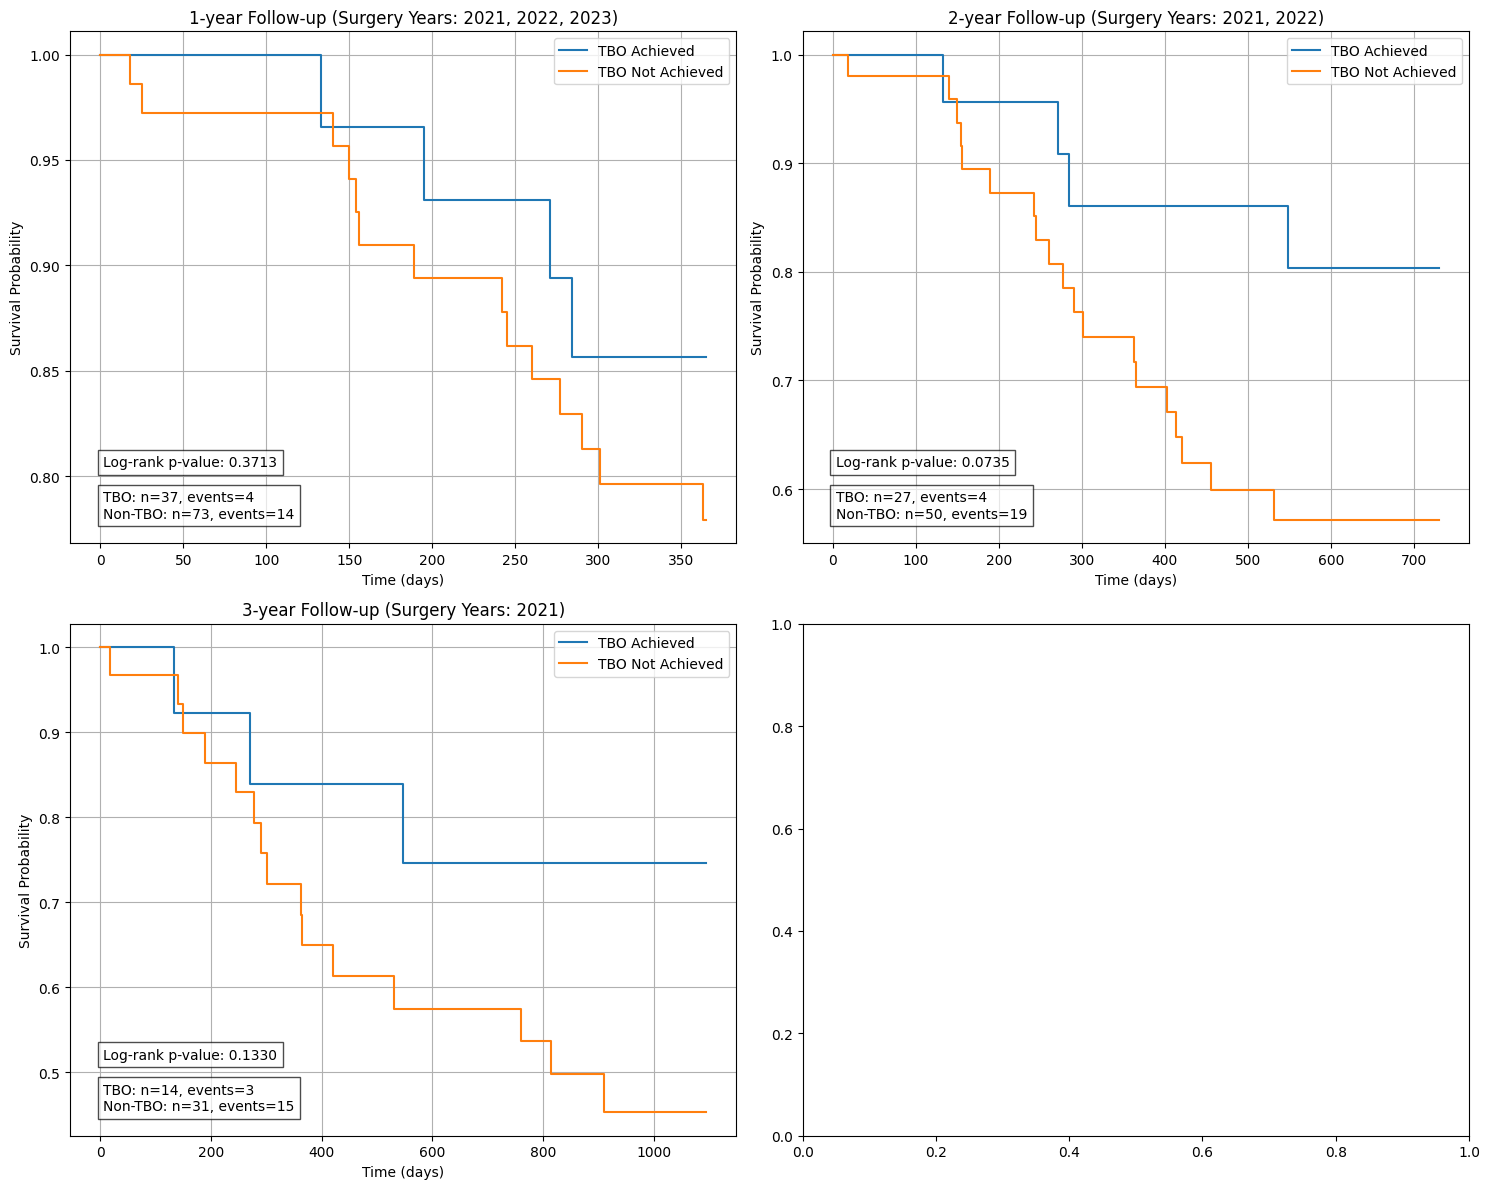

Survival curves generated and saved as 'survival_curves_by_follow_up.png'

--- GENERATING OVERALL SURVIVAL AND RECURRENCE CURVES ---


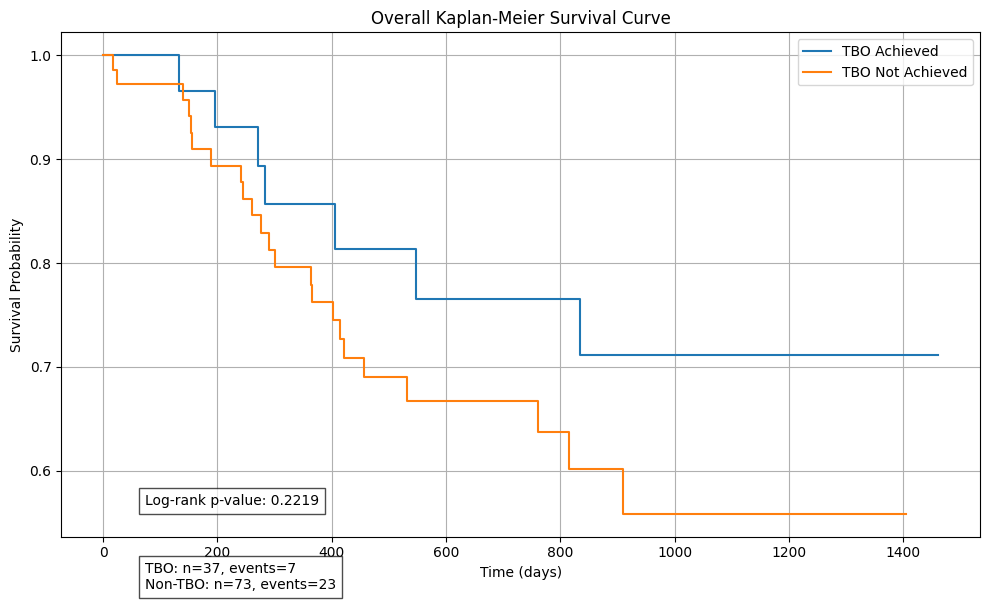

Overall survival curve generated and saved as 'overall_survival_curve.png'


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Define follow-up groups based on surgery year
follow_up_groups = {
    '1-year': [2021, 2022, 2023],
    '2-year': [2021, 2022],
    '3-year': [2021],
    #'4-year': [2021]
}

# PART 1: Filter to include only patients in patient_outcomes
print("--- FILTERING PATIENTS ---")
patients_in_analysis = list(patient_outcomes.keys())
print(f"Total patients in analysis (from patient_outcomes): {len(patients_in_analysis)}")

# PART 2: Prepare data and generate summary table
print("\n--- SUMMARY TABLE FOR ABSTRACT SUBMISSION ---")

# Find earliest operation date for each patient (changed from latest to earliest)
patient_op_dates = {}
for _, row in merged_final_tsqic_redcap_access.iterrows():
    patient_id = row['id']
    operation_date = row['operation_date']
    
    if pd.notna(operation_date):
        # Changed from > to < to track earliest date instead of latest
        if patient_id not in patient_op_dates or operation_date < patient_op_dates[patient_id]:
            patient_op_dates[patient_id] = operation_date

# Add surgery year to each patient
patient_years = {}
for patient_id, op_date in patient_op_dates.items():
    if pd.notna(op_date) and patient_id in patients_in_analysis:  # Only include patients in analysis
        patient_years[patient_id] = op_date.year

print(f"Patients with surgery dates: {len(patient_years)}")

# Summary table data
summary_data = []

for period, years in follow_up_groups.items():
    # Get patients for this follow-up period
    period_patients = [pid for pid, year in patient_years.items() if year in years]
    
    # Count TBO and non-TBO patients
    tbo_count = sum(1 for pid in period_patients if pid in patient_outcomes and patient_outcomes[pid])
    non_tbo_count = sum(1 for pid in period_patients if pid in patient_outcomes and not patient_outcomes[pid])
    
    # Add to summary data
    summary_data.append({
        'Follow-up Period': period,
        'Surgery Years': ', '.join(map(str, years)),
        'Total Patients': len(period_patients),
        'TBO Achieved': tbo_count,
        'TBO Not Achieved': non_tbo_count,
        'TBO Rate': f"{tbo_count / len(period_patients):.1%}" if len(period_patients) > 0 else "N/A"
    })

# Create and display summary table
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# PART 3: Prepare patient-level dataset for survival curves and recurrence tables
patient_data = []

for patient_id, op_date in patient_op_dates.items():
    # Only include patients in analysis
    if pd.notna(op_date) and patient_id in patients_in_analysis:
        # Get all rows for this patient
        pt_rows = merged_final_tsqic_redcap_access[merged_final_tsqic_redcap_access['id'] == patient_id]
        
        # Get surgery year
        surgery_year = op_date.year
        
        # Check if patient died
        died = pt_rows['dod'].notna().any()
        death_date = pt_rows.loc[pt_rows['dod'].notna(), 'dod'].iloc[0] if died and any(pt_rows['dod'].notna()) else None
        
        # Calculate survival time
        if died and death_date is not None:
            survival_time = (death_date - op_date).days
            death_event = 1
        else:
            # Get the latest follow-up date
            last_fu = pt_rows['last_fu_date'].max() if any(pt_rows['last_fu_date'].notna()) else None
            if last_fu is not None:
                survival_time = (last_fu - op_date).days
            else:
                survival_time = np.nan
            death_event = 0
        
        # Convert survival_time to float to ensure compatibility
        if pd.notna(survival_time):
            survival_time = float(survival_time)
        
        # Get DFS value if available
        if 'dfs' in pt_rows.columns:
            dfs = pt_rows['dfs'].dropna()
            dfs_value = dfs.iloc[0] if len(dfs) > 0 else np.nan
        else:
            dfs_value = np.nan
        
        # Check for recurrence and metastasis
        has_recurrence = (pt_rows['recurrence'] == 1).any()
        has_metastasis = (pt_rows['recurrence_location___distant'] == 1).any()
        
        # TBO status
        tbo_status = patient_outcomes.get(patient_id, False)
        
        # Add to dataset
        patient_data.append({
            'patient_id': patient_id,
            'surgery_year': surgery_year,
            'tbo': tbo_status,
            'survival_time': survival_time,
            'death_event': death_event,
            'dfs': dfs_value,
            'recurrence': has_recurrence,
            'metastasis': has_metastasis
        })

patient_df = pd.DataFrame(patient_data)
print(f"Patient data created: {len(patient_df)} patients")

# PART 4: Create tables comparing recurrence and metastasis by TBO status for each follow-up period
print("\n--- RECURRENCE AND METASTASIS TABLES BY FOLLOW-UP PERIOD ---")

for period, years in follow_up_groups.items():
    # Filter for patients in this follow-up period
    period_df = patient_df[patient_df['surgery_year'].isin(years)]
    
    
    if period == '1-year':
        max_days = 365
    elif period == '2-year':
        max_days = 730
    elif period == '3-year':
        max_days = 1095
    
    # Truncate survival times and adjust events
    period_df['survival_time'] = np.minimum(period_df['survival_time'], max_days)
    period_df['death_event'] = np.where(
        period_df['survival_time'] < max_days,# If they died before the cutoff
        period_df['death_event'],# Keep original event status
        0# Otherwise, censor them (no event)
    )
    
    
    
    # Skip if no patients in this period
    if len(period_df) == 0:
        continue
    
    print(f"\n{period} Follow-up (Surgery Years: {', '.join(map(str, years))})")
    
    # Split by TBO status
    tbo_patients = period_df[period_df['tbo'] == True]
    non_tbo_patients = period_df[period_df['tbo'] == False]
    
    # Calculate recurrence rates
    tbo_recurrence_count = tbo_patients['recurrence'].sum() if len(tbo_patients) > 0 else 0
    tbo_recurrence_rate = tbo_recurrence_count / len(tbo_patients) if len(tbo_patients) > 0 else 0
    
    non_tbo_recurrence_count = non_tbo_patients['recurrence'].sum() if len(non_tbo_patients) > 0 else 0
    non_tbo_recurrence_rate = non_tbo_recurrence_count / len(non_tbo_patients) if len(non_tbo_patients) > 0 else 0
    
    # Calculate metastasis rates
    tbo_metastasis_count = tbo_patients['metastasis'].sum() if len(tbo_patients) > 0 else 0
    tbo_metastasis_rate = tbo_metastasis_count / len(tbo_patients) if len(tbo_patients) > 0 else 0
    
    non_tbo_metastasis_count = non_tbo_patients['metastasis'].sum() if len(non_tbo_patients) > 0 else 0
    non_tbo_metastasis_rate = non_tbo_metastasis_count / len(non_tbo_patients) if len(non_tbo_patients) > 0 else 0
    
    # Create table
    data = {
        'Group': ['TBO Achieved', 'TBO Not Achieved'],
        'Patients': [len(tbo_patients), len(non_tbo_patients)],
        'Recurrence': [
            f"{int(tbo_recurrence_count)}/{len(tbo_patients)} ({tbo_recurrence_rate:.1%})" if len(tbo_patients) > 0 else "0/0 (N/A)",
            f"{int(non_tbo_recurrence_count)}/{len(non_tbo_patients)} ({non_tbo_recurrence_rate:.1%})" if len(non_tbo_patients) > 0 else "0/0 (N/A)"
        ],
        'Metastasis': [
            f"{int(tbo_metastasis_count)}/{len(tbo_patients)} ({tbo_metastasis_rate:.1%})" if len(tbo_patients) > 0 else "0/0 (N/A)",
            f"{int(non_tbo_metastasis_count)}/{len(non_tbo_patients)} ({non_tbo_metastasis_rate:.1%})" if len(non_tbo_patients) > 0 else "0/0 (N/A)"
        ]
    }
    
    period_table = pd.DataFrame(data)
    print(period_table.to_string(index=False))
    
    # Perform statistical tests if there's enough data
    if len(tbo_patients) > 0 and len(non_tbo_patients) > 0:
        # Log-rank test for survival if there are events
        if tbo_patients['death_event'].sum() > 0 or non_tbo_patients['death_event'].sum() > 0:
            # Filter to valid survival data
            tbo_surv = tbo_patients.dropna(subset=['survival_time', 'death_event'])
            non_tbo_surv = non_tbo_patients.dropna(subset=['survival_time', 'death_event'])
            
            if len(tbo_surv) > 0 and len(non_tbo_surv) > 0:
                try:
                    results = logrank_test(
                        tbo_surv['survival_time'].astype(float),
                        non_tbo_surv['survival_time'].astype(float),
                        tbo_surv['death_event'].astype(int),
                        non_tbo_surv['death_event'].astype(int)
                    )
                    print(f"Survival log-rank test p-value: {results.p_value:.4f}")
                except Exception as e:
                    print(f"Could not perform survival log-rank test: {e}")

# PART 5: Create Kaplan-Meier survival curves by TBO status for each follow-up period
print("\n--- GENERATING SURVIVAL CURVES ---")

try:
    # Set up the figure with 4 subplots (one for each follow-up period)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    # Generate survival curves for each follow-up period
    for i, (period, years) in enumerate(follow_up_groups.items()):
        # Filter patients for this period
        period_df = patient_df[patient_df['surgery_year'].isin(years)]
        
        if period == '1-year':
            max_days = 365
        elif period == '2-year':
            max_days = 730
        elif period == '3-year':
            max_days = 1095
        
        # Truncate survival times and adjust events
        period_df['survival_time'] = np.minimum(period_df['survival_time'], max_days)
        period_df['death_event'] = np.where(
            period_df['survival_time'] < max_days,
            period_df['death_event'],
            0
        )
        
        
        # Skip if no patients
        if len(period_df) == 0:
            axes[i].text(0.5, 0.5, f"No data for {period}", 
                       ha='center', va='center', fontsize=12)
            axes[i].set_title(f'{period} Follow-up (Surgery Years: {", ".join(map(str, years))})')
            continue
        
        # Split by TBO status
        tbo_patients = period_df[period_df['tbo'] == True].copy()
        non_tbo_patients = period_df[period_df['tbo'] == False].copy()
        
        # Initialize Kaplan-Meier fitter
        kmf = KaplanMeierFitter()
        
        # Plot for TBO group
        if len(tbo_patients) > 0:
            # Ensure data is clean and numeric
            valid_tbo = tbo_patients.dropna(subset=['survival_time', 'death_event'])
            if len(valid_tbo) > 0:
                # Convert to numeric to avoid type issues
                surv_times = valid_tbo['survival_time'].astype(float).values
                events = valid_tbo['death_event'].astype(int).values
                
                # Fit and plot KM curve
                kmf.fit(surv_times, events, label='TBO Achieved')
                kmf.plot_survival_function(ax=axes[i], ci_show=False)
        
        # Plot for non-TBO group
        if len(non_tbo_patients) > 0:
            # Ensure data is clean and numeric
            valid_non_tbo = non_tbo_patients.dropna(subset=['survival_time', 'death_event'])
            if len(valid_non_tbo) > 0:
                # Convert to numeric to avoid type issues
                surv_times = valid_non_tbo['survival_time'].astype(float).values
                events = valid_non_tbo['death_event'].astype(int).values
                
                # Fit and plot KM curve
                kmf.fit(surv_times, events, label='TBO Not Achieved')
                kmf.plot_survival_function(ax=axes[i], ci_show=False)
        
        # Add labels and title
        axes[i].set_title(f'{period} Follow-up (Surgery Years: {", ".join(map(str, years))})')
        axes[i].set_xlabel('Time (days)')
        axes[i].set_ylabel('Survival Probability')
        axes[i].grid(True)
        
        # Add legend if curves were plotted
        if (len(tbo_patients) > 0 and len(tbo_patients.dropna(subset=['survival_time'])) > 0) or \
           (len(non_tbo_patients) > 0 and len(non_tbo_patients.dropna(subset=['survival_time'])) > 0):
            axes[i].legend()
        
        # Add number at risk information
        tbo_events = tbo_patients['death_event'].sum() if len(tbo_patients) > 0 else 0
        non_tbo_events = non_tbo_patients['death_event'].sum() if len(non_tbo_patients) > 0 else 0
        
        axes[i].text(0.05, 0.05, 
                    f'TBO: n={len(tbo_patients)}, events={int(tbo_events)}\n'
                    f'Non-TBO: n={len(non_tbo_patients)}, events={int(non_tbo_events)}',
                    transform=axes[i].transAxes, 
                    bbox=dict(facecolor='white', alpha=0.7))
        
        # Add log-rank p-value if possible
        if len(tbo_patients) > 0 and len(non_tbo_patients) > 0:
            # Filter to valid survival data
            tbo_surv = tbo_patients.dropna(subset=['survival_time', 'death_event'])
            non_tbo_surv = non_tbo_patients.dropna(subset=['survival_time', 'death_event'])
            
            if len(tbo_surv) > 0 and len(non_tbo_surv) > 0:
                try:
                    results = logrank_test(
                        tbo_surv['survival_time'].astype(float),
                        non_tbo_surv['survival_time'].astype(float),
                        tbo_surv['death_event'].astype(int),
                        non_tbo_surv['death_event'].astype(int)
                    )
                    p_val = results.p_value
                    axes[i].text(0.05, 0.15, 
                                f'Log-rank p-value: {p_val:.4f}',
                                transform=axes[i].transAxes, 
                                bbox=dict(facecolor='white', alpha=0.7))
                except Exception as e:
                    pass
    
    plt.tight_layout()
    plt.show()
    
    print("Survival curves generated and saved as 'survival_curves_by_follow_up.png'")
    
    # PART 6: Also generate overall Kaplan-Meier survival and recurrence curves (not split by follow-up period)
    print("\n--- GENERATING OVERALL SURVIVAL AND RECURRENCE CURVES ---")
    
    # Set up figure for overall survival
    plt.figure(figsize=(10, 6))
    kmf = KaplanMeierFitter()
    
    # Split by TBO status
    tbo_overall = patient_df[patient_df['tbo'] == True].copy()
    non_tbo_overall = patient_df[patient_df['tbo'] == False].copy()
    
    # Plot for TBO group
    if len(tbo_overall) > 0:
        valid_tbo = tbo_overall.dropna(subset=['survival_time', 'death_event'])
        if len(valid_tbo) > 0:
            surv_times = valid_tbo['survival_time'].astype(float).values
            events = valid_tbo['death_event'].astype(int).values
            
            kmf.fit(surv_times, events, label='TBO Achieved')
            kmf.plot_survival_function(ci_show=False)
    
    # Plot for non-TBO group
    if len(non_tbo_overall) > 0:
        valid_non_tbo = non_tbo_overall.dropna(subset=['survival_time', 'death_event'])
        if len(valid_non_tbo) > 0:
            surv_times = valid_non_tbo['survival_time'].astype(float).values
            events = valid_non_tbo['death_event'].astype(int).values
            
            kmf.fit(surv_times, events, label='TBO Not Achieved')
            kmf.plot_survival_function(ci_show=False)
    
    # Add labels and title
    plt.title('Overall Kaplan-Meier Survival Curve')
    plt.xlabel('Time (days)')
    plt.ylabel('Survival Probability')
    plt.grid(True)
    plt.legend()
    
    # Add number at risk information
    tbo_events = tbo_overall['death_event'].sum() if len(tbo_overall) > 0 else 0
    non_tbo_events = non_tbo_overall['death_event'].sum() if len(non_tbo_overall) > 0 else 0
    
    plt.figtext(0.15, 0.01, 
                f'TBO: n={len(tbo_overall)}, events={int(tbo_events)}\n'
                f'Non-TBO: n={len(non_tbo_overall)}, events={int(non_tbo_events)}',
                bbox=dict(facecolor='white', alpha=0.7))
    
    # Add log-rank p-value if possible
    if len(tbo_overall) > 0 and len(non_tbo_overall) > 0:
        # Filter to valid survival data
        tbo_surv = tbo_overall.dropna(subset=['survival_time', 'death_event'])
        non_tbo_surv = non_tbo_overall.dropna(subset=['survival_time', 'death_event'])
        
        if len(tbo_surv) > 0 and len(non_tbo_surv) > 0:
            try:
                results = logrank_test(
                    tbo_surv['survival_time'].astype(float),
                    non_tbo_surv['survival_time'].astype(float),
                    tbo_surv['death_event'].astype(int),
                    non_tbo_surv['death_event'].astype(int)
                )
                p_val = results.p_value
                plt.figtext(0.15, 0.15, 
                            f'Log-rank p-value: {p_val:.4f}',
                            bbox=dict(facecolor='white', alpha=0.7))
            except Exception as e:
                pass
    
    plt.tight_layout()
    plt.show()
    
    print("Overall survival curve generated and saved as 'overall_survival_curve.png'")
    
except Exception as e:
    print(f"Error generating survival curves: {e}")
    print("Printing survival data availability for debugging:")
    
    # Print actual survival data availability for debugging
    print("\n--- SURVIVAL DATA AVAILABILITY ---")
    for period, years in follow_up_groups.items():
        period_df = patient_df[patient_df['surgery_year'].isin(years)]
        
        # Skip if no patients
        if len(period_df) == 0:
            print(f"{period}: No patients")
            continue
        
        # Split by TBO status
        tbo_patients = period_df[period_df['tbo'] == True]
        non_tbo_patients = period_df[period_df['tbo'] == False]
        
        print(f"\n{period} (Years: {', '.join(map(str, years))})")
        
        # Check TBO group
        tbo_with_survival = tbo_patients.dropna(subset=['survival_time']).shape[0]
        tbo_with_events = tbo_patients['death_event'].sum() if len(tbo_patients) > 0 else 0
        print(f"  TBO patients: {len(tbo_patients)}")
        print(f"  TBO patients with survival data: {tbo_with_survival}")
        print(f"  TBO patients with death events: {int(tbo_with_events)}")
        
        # Check non-TBO group
        non_tbo_with_survival = non_tbo_patients.dropna(subset=['survival_time']).shape[0]
        non_tbo_with_events = non_tbo_patients['death_event'].sum() if len(non_tbo_patients) > 0 else 0
        print(f"  Non-TBO patients: {len(non_tbo_patients)}")
        print(f"  Non-TBO patients with survival data: {non_tbo_with_survival}")
        print(f"  Non-TBO patients with death events: {int(non_tbo_with_events)}")

### FACTE

In [43]:
patients_in_analysis = list(patient_outcomes.keys())
# filtered_merged_final_tsqic_redcap_access[filtered_merged_final_tsqic_redcap_access['id'].isin(patients_in_analysis)]

filtered_merged_final_tsqic_redcap_access[
    (filtered_merged_final_tsqic_redcap_access['id'].isin(patients_in_analysis)) &
    (filtered_merged_final_tsqic_redcap_access['redcap_event_name'] == "1_month_postop_arm_1")
]


,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,los,redcap_event_name,redcap_repeat_instrument,...,a_e6,a_c6,a_e7,a_act11,a_c2,ecs_answr,ecs_score,toi_score,fact_totalscore,functional_assessment_of_cancer_therapy_fact_esoph_complete
4297,1113,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,functional_assessment_of_cancer_therapy_fact_e...,...,0.0,0.0,0.0,0.0,1.0,17.0,28.0,75.0,127.0,2.0
4299,1113,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4322,1122,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4371,1135,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4400,1141,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5879,1581,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5882,1581,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,functional_assessment_of_cancer_therapy_fact_e...,...,0.0,1.0,4.0,3.0,1.0,17.0,18.0,24.0,NaN,2.0
5954,1601,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6000,1612,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
patients_in_analysis = list(patient_outcomes.keys())
patient_df[patient_df['patient_id'].isin(patients_in_analysis)]

,patient_id,surgery_year,tbo,survival_time,death_event,dfs,recurrence,metastasis
0,1113,2021,False,519.0,0,519.0,False,False
1,1122,2021,False,1310.0,0,1310.0,False,False
2,1135,2021,False,18.0,1,18.0,False,False
3,1141,2021,False,290.0,1,199.0,True,False
4,1145,2021,False,1405.0,0,1405.0,False,False
...,...,...,...,...,...,...,...,...
105,1601,2023,False,392.0,0,392.0,False,False
106,1603,2023,False,57.0,0,57.0,False,False
107,1612,2023,True,26.0,0,26.0,False,False
108,1616,2023,True,575.0,0,575.0,False,False


In [45]:
# Step 1: Get the TBO study patients and calculate FACT-E scores
patients_in_analysis = list(patient_outcomes.keys())
# tbo_study_df = filtered_merged_final_tsqic_redcap_access[
#     filtered_merged_final_tsqic_redcap_access['id'].isin(patients_in_analysis)
# ]

tbo_study_df = filtered_merged_final_tsqic_redcap_access[
    (filtered_merged_final_tsqic_redcap_access['id'].isin(patients_in_analysis)) &
    (filtered_merged_final_tsqic_redcap_access['redcap_event_name'] == "1_month_postop_arm_1")
]

print(f"TBO study patients: {len(patients_in_analysis)}")
print(f"Rows in TBO study dataset: {len(tbo_study_df)}")

TBO study patients: 110
Rows in TBO study dataset: 122


In [46]:
# Step 2: Calculate FACT-E scores using the existing function
def calculate_subscale_score(df, cols, reverse_items=None, subscale_name=""):
    """Calculate subscale scores according to FACT scoring guidelines, only if >=50% items are answered"""
    # Convert to numeric and handle reverse scoring
    for col in cols:
        df[f"{col}_score"] = pd.to_numeric(df[col], errors='coerce')
        if reverse_items and col in reverse_items:
            df[f"{col}_score"] = 4 - df[f"{col}_score"]
    
    # Calculate the number of items and the 50% threshold
    total_items = len(cols)
    min_items_required = total_items / 2  # 50% threshold
    
    # Count non-NaN items for each row
    score_cols = [f"{col}_score" for col in cols]
    num_answered_items = df[score_cols].notna().sum(axis=1)
    
    # Calculate subscale score only if >=50% items are answered
    df[f"{subscale_name}_subscale_score"] = np.where(
        num_answered_items >= min_items_required,
        (df[score_cols].sum(axis=1, skipna=True) * total_items) / 
        df[score_cols].notna().sum(axis=1),
        np.nan
    )
    return df

def calculate_all_scores(df):
    pwb_cols = [f"gp{i}" for i in range(1, 8)]
    swb_cols = [f"gs{i}" for i in range(1, 8)]
    ewb_cols = [f"ge{i}" for i in range(1, 7)]
    fwb_cols = [f"gf{i}" for i in range(1, 8)]
    ecs_cols = [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + \
                [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]

    pwb_reverse = pwb_cols
    ewb_reverse = [f"ge{i}" for i in range(1, 7) if i != 2]
    ecs_reverse = ["a_e1", "a_e2", "a_e3", "a_e4", "a_e5", "a_e7", "a_act11", 
                    "a_c2", "a_hn2", "a_hn3"]

    df = calculate_subscale_score(df, pwb_cols, pwb_reverse, "pwb")
    df = calculate_subscale_score(df, swb_cols, None, "swb")
    df = calculate_subscale_score(df, ewb_cols, ewb_reverse, "ewb")
    df = calculate_subscale_score(df, fwb_cols, None, "fwb")
    df = calculate_subscale_score(df, ecs_cols, ecs_reverse, "ecs")

    # Calculate composite scores with both conditions
    # 1. FACT-G Total (PWB + SWB + EWB + FWB)
    fact_g_items = pwb_cols + swb_cols + ewb_cols + fwb_cols  # 27 items
    fact_g_item_cols = [f"{col}_score" for col in fact_g_items]
    fact_g_num_answered = df[fact_g_item_cols].notna().sum(axis=1)
    fact_g_min_items = 22  # 80% of 27 items = 21.6, rounded up to 22
    
    df['fact_g_total'] = np.where(
        # Condition 1: All subscales must be non-NaN (already ensures 50% of items per subscale)
        (df["pwb_subscale_score"].notna()) & 
        (df["swb_subscale_score"].notna()) & 
        (df["ewb_subscale_score"].notna()) & 
        (df["fwb_subscale_score"].notna()) &
        # Condition 2: At least 80% of FACT-G items must be answered
        (fact_g_num_answered >= fact_g_min_items),
        df["pwb_subscale_score"] + df["swb_subscale_score"] + 
        df["ewb_subscale_score"] + df["fwb_subscale_score"],
        np.nan
    )
    
    # 2. FACT-E Total (FACT-G + ECS)
    fact_e_items = fact_g_items + ecs_cols  # 27 + 17 = 44 items
    fact_e_item_cols = [f"{col}_score" for col in fact_e_items]
    fact_e_num_answered = df[fact_e_item_cols].notna().sum(axis=1)
    fact_e_min_items = 36  # 80% of 44 items = 35.2, rounded up to 36
    
    df['fact_e_total'] = np.where(
        # Condition 1: FACT-G and ECS must be non-NaN
        (df['fact_g_total'].notna()) & 
        (df["ecs_subscale_score"].notna()) &
        # Condition 2: At least 80% of FACT-E items must be answered
        (fact_e_num_answered >= fact_e_min_items),
        df['fact_g_total'] + df["ecs_subscale_score"],
        np.nan
    )
    
    return df

In [47]:
tbo_study_with_scores = calculate_all_scores(tbo_study_df.copy())
tbo_study_with_scores

,id,operation_date,Complication,Grade,GradeLetter,readmission_30d,DischargeDate,los,redcap_event_name,redcap_repeat_instrument,...,a_e4_score,a_e5_score,a_e6_score,a_e7_score,a_c6_score,a_c2_score,a_act11_score,ecs_subscale_score,fact_g_total,fact_e_total
4297,1113,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,functional_assessment_of_cancer_therapy_fact_e...,...,4.0,4.0,0.0,4.0,0.0,3.0,4.0,28.0,99.0,127.0
4299,1113,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4322,1122,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4371,1135,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4400,1141,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5879,1581,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5882,1581,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,functional_assessment_of_cancer_therapy_fact_e...,...,0.0,0.0,0.0,0.0,1.0,3.0,1.0,18.0,21.2,39.2
5954,1601,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6000,1612,NaT,NaN,NaN,NaN,NaN,NaT,NaN,1_month_postop_arm_1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
# Step 4: Get patient-level FACT-E scores (take the most recent non-NaN score per patient)
patient_fact_e_scores = []

for patient_id in patients_in_analysis:
    patient_rows = tbo_study_with_scores[tbo_study_with_scores['id'] == patient_id]
    
    # Get all non-NaN FACT-E scores for this patient
    fact_e_scores = patient_rows['fact_e_total'].dropna()
    
    if len(fact_e_scores) > 0:
        # Take the most recent (last) non-NaN score
        fact_e_score = fact_e_scores.iloc[-1]
        patient_fact_e_scores.append({
            'patient_id': patient_id,
            'fact_e_total': fact_e_score
        })
        if len(fact_e_scores) > 1:
            print(f"Warning: Multiple FACT-E scores found for patient {patient_id}. Using the most recent score: {fact_e_score:.2f}")

# Convert to DataFrame
fact_e_df = pd.DataFrame(patient_fact_e_scores)

print(f"Patients with FACT-E scores: {len(fact_e_df)}")
fact_e_df

Patients with FACT-E scores: 47


,patient_id,fact_e_total
0,1113,127.000000
1,1141,110.166667
2,1145,136.600000
3,1150,112.000000
4,1167,128.000000
5,1175,101.000000
6,1176,111.000000
7,1182,133.000000
8,1188,110.000000
9,1189,144.666667


In [49]:
# Step 5: Merge with TBO status from patient_df
tbo_patients_df = patient_df[patient_df['patient_id'].isin(patients_in_analysis)]

# Merge FACT-E scores with TBO status
combined_df = tbo_patients_df[['patient_id', 'tbo']].merge(
    fact_e_df, 
    on='patient_id', 
    how='inner'
)

print(f"Patients with both FACT-E scores and TBO status: {len(combined_df)}")
combined_df

Patients with both FACT-E scores and TBO status: 47


,patient_id,tbo,fact_e_total
0,1113,False,127.000000
1,1141,False,110.166667
2,1145,False,136.600000
3,1150,True,112.000000
4,1167,False,128.000000
5,1175,False,101.000000
6,1176,False,111.000000
7,1182,True,133.000000
8,1188,True,110.000000
9,1189,True,144.666667


In [50]:
# Step 6: Compare FACT-E score distributions between TBO and non-TBO groups
tbo_group = combined_df[combined_df['tbo'] == True]
non_tbo_group = combined_df[combined_df['tbo'] == False]

print(f"\nFACT-E Score Analysis:")
print(f"TBO group: {len(tbo_group)} patients")
print(f"Non-TBO group: {len(non_tbo_group)} patients")

# Descriptive statistics
print(f"\nDescriptive Statistics:")
print(f"TBO Group FACT-E scores:")
print(f"  Mean: {tbo_group['fact_e_total'].mean():.2f}")
print(f"  Median: {tbo_group['fact_e_total'].median():.2f}")
print(f"  Std: {tbo_group['fact_e_total'].std():.2f}")
print(f"  Min: {tbo_group['fact_e_total'].min():.2f}")
print(f"  Max: {tbo_group['fact_e_total'].max():.2f}")

print(f"\nNon-TBO Group FACT-E scores:")
print(f"  Mean: {non_tbo_group['fact_e_total'].mean():.2f}")
print(f"  Median: {non_tbo_group['fact_e_total'].median():.2f}")
print(f"  Std: {non_tbo_group['fact_e_total'].std():.2f}")
print(f"  Min: {non_tbo_group['fact_e_total'].min():.2f}")
print(f"  Max: {non_tbo_group['fact_e_total'].max():.2f}")


FACT-E Score Analysis:
TBO group: 18 patients
Non-TBO group: 29 patients

Descriptive Statistics:
TBO Group FACT-E scores:
  Mean: 112.78
  Median: 111.55
  Std: 23.93
  Min: 69.00
  Max: 151.00

Non-TBO Group FACT-E scores:
  Mean: 108.75
  Median: 110.17
  Std: 24.69
  Min: 39.20
  Max: 154.00


In [51]:
# Statistical test (Mann-Whitney U test for non-parametric comparison)
from scipy.stats import mannwhitneyu, ttest_ind

# Perform Mann-Whitney U test
statistic, p_value = mannwhitneyu(
    tbo_group['fact_e_total'], 
    non_tbo_group['fact_e_total'], 
    alternative='greater'
)

print(f"\nMann-Whitney U Test:")
print(f"  Statistic: {statistic:.2f}")
print(f"  P-value: {p_value:.4f}")

if p_value < 0.05:
    print("  There is a statistically significant difference in FACT-E scores between TBO and non-TBO groups")
else:
    print("  There is no statistically significant difference in FACT-E scores between TBO and non-TBO groups")



Mann-Whitney U Test:
  Statistic: 278.00
  P-value: 0.3590
  There is no statistically significant difference in FACT-E scores between TBO and non-TBO groups


In [52]:
# Also perform t-test for comparison
t_stat, t_p_value = ttest_ind(
    tbo_group['fact_e_total'], 
    non_tbo_group['fact_e_total']
)

print(f"\nIndependent t-test:")
print(f"  T-statistic: {t_stat:.2f}")
print(f"  P-value: {t_p_value:.4f}")



Independent t-test:
  T-statistic: 0.55
  P-value: 0.5850


In [53]:
# Create summary table
summary_data = []
for group_name, group_df in [('TBO Achieved', tbo_group), ('TBO Not Achieved', non_tbo_group)]:
    summary_data.append({
        'Group': group_name,
        'N': len(group_df),
        'Mean': f"{group_df['fact_e_total'].mean():.2f}",
        'Median': f"{group_df['fact_e_total'].median():.2f}",
        'Std Dev': f"{group_df['fact_e_total'].std():.2f}",
        'Min': f"{group_df['fact_e_total'].min():.2f}",
        'Max': f"{group_df['fact_e_total'].max():.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print(f"\nFACT-E Score Summary Table:")
print(summary_df.to_string(index=False))


FACT-E Score Summary Table:
           Group  N   Mean Median Std Dev   Min    Max
    TBO Achieved 18 112.78 111.55   23.93 69.00 151.00
TBO Not Achieved 29 108.75 110.17   24.69 39.20 154.00


/tmp/ipykernel_4020410/2504844662.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([tbo_group['fact_e_total'], non_tbo_group['fact_e_total']],


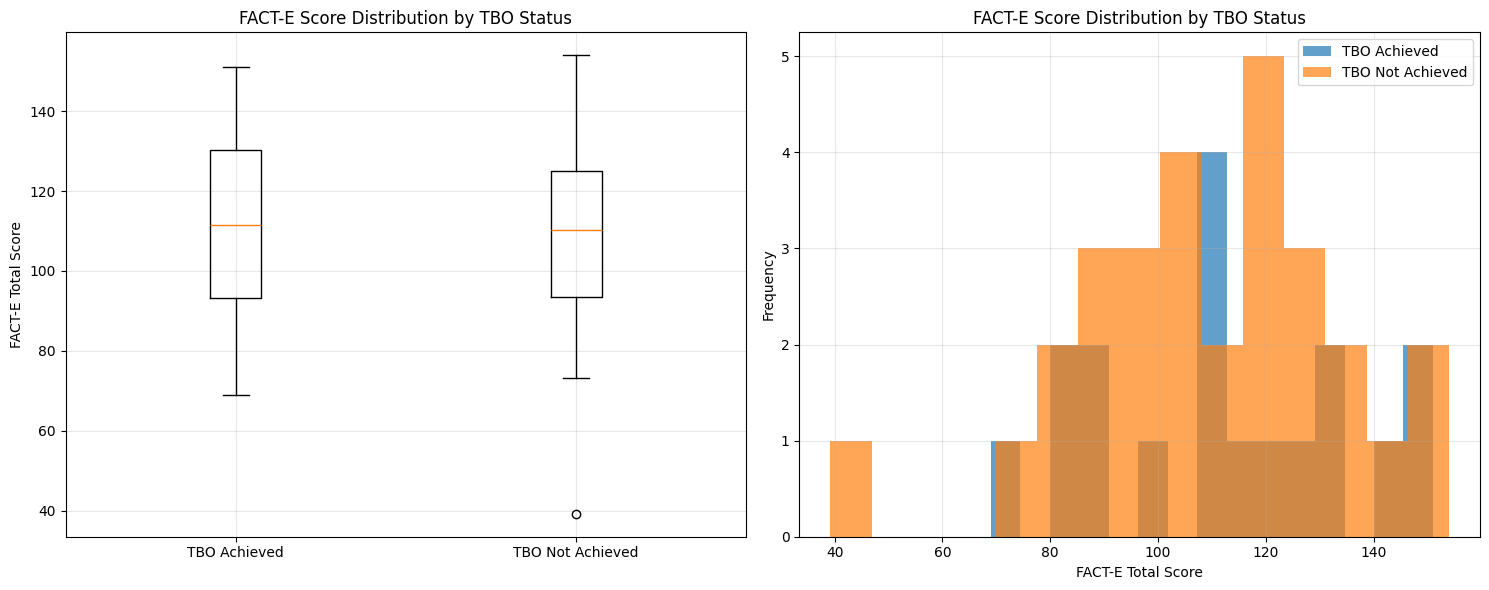


Final Dataset Shape: (47, 3)
Columns: ['patient_id', 'tbo', 'fact_e_total']


In [54]:
# Create visualization
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Box plot
ax1.boxplot([tbo_group['fact_e_total'], non_tbo_group['fact_e_total']], 
            labels=['TBO Achieved', 'TBO Not Achieved'])
ax1.set_title('FACT-E Score Distribution by TBO Status')
ax1.set_ylabel('FACT-E Total Score')
ax1.grid(True, alpha=0.3)

# Histogram
ax2.hist(tbo_group['fact_e_total'], alpha=0.7, label='TBO Achieved', bins=15)
ax2.hist(non_tbo_group['fact_e_total'], alpha=0.7, label='TBO Not Achieved', bins=15)
ax2.set_title('FACT-E Score Distribution by TBO Status')
ax2.set_xlabel('FACT-E Total Score')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Dataset Shape: {combined_df.shape}")
print(f"Columns: {list(combined_df.columns)}")
